In [7]:
import pandas as pd
import numpy as np
# visualization
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.cbook import boxplot_stats
from IPython.display import Image

# preprocessing (pre-modeling)
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# modeling
import statsmodels.api as sm
from sklearn.neighbors import KNeighborsClassifier

# evaluation (post-modeling)
from sklearn.metrics import *
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from scipy.special import logit

from tkinter import *
from matplotlib.figure import Figure
from matplotlib.backends.backend_tkagg import (FigureCanvasTkAgg,
NavigationToolbar2Tk)
from tkinter import filedialog
from PIL import ImageTk, Image  
import tkinter.ttk as ttk
#*****************************************************************************************************

import warnings
warnings.filterwarnings("ignore")
sns.set(style="ticks", color_codes=True)
pd.options.display.float_format = '{:.5f}'.format
pd.options.display.max_colwidth = None

#************************Important Processing Functions*********
def plotCorrelationHeatmap(data, figsize = (12,6)):
    plt.figure(figsize=figsize)
    corr_val = data.corr(method = "pearson")
    mask = np.zeros_like(corr_val, dtype = bool)
    mask[np.triu_indices_from(mask, k = 1)] = True
    corr_heatmap = sns.heatmap(corr_val, mask = mask,
                               annot = True, fmt='.3f', linewidths = 3, cmap = "Reds")
    corr_heatmap.set_title("PEARSON CORRELATION HEATMAP", fontsize = 15, fontweight = "bold")
    corr_heatmap

def plotDiseaseCount(data):
    ax = data.groupby(['Disease', 'Gender']).size().unstack().plot(kind='bar', stacked=True)
    for rect in ax.patches:
        height = rect.get_height()
        width = rect.get_width()
        padding = 0.25

        ax.text(rect.get_x() + width - padding, 
                rect.get_y() + height / 2, 
                int(height), 
                ha = 'center', va = 'center',
                color = "white")

def upsampleData(data):
    data_majority = data[data["Disease"] == "Yes"]
    data_minority = data[data["Disease"] == "No"]
    data_minority_upsampled = resample(data_minority,
                                       n_samples = data_majority.shape[0],
                                       replace = True,
                                       random_state = 888)
    data_upsampled = pd.concat([data_majority, data_minority_upsampled])
    return data_upsampled

def fitLogisticRegression(X, y):
    model = sm.Logit(y, sm.add_constant(X))
    result = model.fit()
    return result

def boxPlotTransformedData(liver,data, figsize = (10,4)):
    fig, axes = plt.subplots(1, data.shape[1]-1, figsize = figsize)
    for ax, col in zip(axes, data.columns[:-1]):
        sns.boxplot(x = "Disease", y = col, data = data, ax = ax)
        # Outlier Count
        outlier_count = 0
        for flag in data["Disease"].cat.categories:
            flag_disease = data.loc[data["Disease"] == flag, col]
            outlier_list = boxplot_stats(flag_disease).pop(0)['fliers']
            outlier_count += len(outlier_list)
        ax.set_title("Outlier Count: {} ({:.2f}%)".format(outlier_count, 100*outlier_count/liver.shape[0]))
    plt.tight_layout()

def evaluateLogReg(result, X_true, y_true):
    eval_list = []
    y_pred_prob = result.predict(sm.add_constant(X_true))
    for threshold in np.linspace(0, 0.99, 50):
        y_pred_cl = (y_pred_prob > threshold).astype(int)
        eval_res = {
            "Threshold": threshold,
            "Recall": recall_score(y_true, y_pred_cl),
            "Precision": precision_score(y_true, y_pred_cl),
            "F1": f1_score(y_true, y_pred_cl),
            "Accuracy": accuracy_score(y_true, y_pred_cl),
            "MCC": matthews_corrcoef(y_true, y_pred_cl)
        }
        eval_list.append(eval_res)
    eval_df = pd.DataFrame(eval_list)
    return eval_df

def scaleData(data, typ):
    if typ == "MinMax":
        scaler = MinMaxScaler()
    elif typ == "Standard":
        scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    data_scaled_df = pd.DataFrame(data_scaled, columns = data.columns)
    return data_scaled_df

def evaluateKNN(X_train, y_train, X_test, y_test, range_k):
    eval_list = []
    for k in range(*range_k, 2):
        knn = KNeighborsClassifier(n_neighbors = k)
        knn.fit(X_train, y_train)
        y_pred_cl = knn.predict(X_test)
        eval_res = {
            "k": k,
            "Recall": recall_score(y_test, y_pred_cl),
            "Precision": precision_score(y_test, y_pred_cl),
            "F1": f1_score(y_test, y_pred_cl),
            "Accuracy": accuracy_score(y_test, y_pred_cl),
            "MCC": matthews_corrcoef(y_test, y_pred_cl)
        }
        eval_list.append(eval_res)
    eval_df = pd.DataFrame(eval_list)
    return eval_df






In [8]:
def plot():
    label_ProgressBar["text"]="Training the Model started. Please wait...."
    label_ProgressBar['bg']="#F9F9C5"
    label_ProgressBar['fg']="#144272"
    progress["value"]=5
    window.update()
    #******************File Reader****************************
    global filename
    liver = pd.read_csv(filename)
    liver.head()
    liver.describe()
    liver.info()
    #****************Assigning short Column names************
    column_names = {
        "Age": "Age",
        "Gender": "Gender",
        "TB": "Total Bilirubin",
        "DB": "Direct Bilirubin",
        "ALP": "Alkaline Phosphotase",
        "ALT": "Alamine Aminotransferase",
        "AST": "Aspartate Aminotransferase",
        "TP": "Total Proteins",
        "Albumin": "Albumin",
        "A/G Ratio": "Albumin and Globulin Ratio",
        "Disease": "Dataset"
    }
    liver.columns = column_names.keys()
    liver.head()
    #***************************Data Preprocessing Starts********
    #***************Normalising the data********************
    liver["Disease"] = liver["Disease"].map({1: "Yes", 2: "No"})
    liver.head()

    liver[["Gender", "Disease"]] = liver[["Gender", "Disease"]].astype("category")
    liver.dtypes
    progress["value"]=10
    window.update()
    for col in liver.select_dtypes('category').columns:
        print(col, ":", liver[col].cat.categories)

    #********************Checking Redundant data****************
    liver.isna().sum()

    #*******************Visualizing HeatMap******************
    plotCorrelationHeatmap(liver.select_dtypes('number'))

    #***********************Normalising ratios*****************
    liver["DB/TB Percentage"] = liver["DB"]/liver["TB"]*100
    #liver["AST/ALT Ratio"] = liver["AST"]/liver["ALT"]**********************
    liver["Globulin"] = liver["Albumin"]/liver["A/G Ratio"]

    liver = liver.drop(["DB", "TB", "A/G Ratio"], axis = 1)
    liver.head()

    #*****************Plotting correlated heatmaps***********************
    plotCorrelationHeatmap(liver.select_dtypes('number'), (14, 6))

    AG_df = liver[["Albumin", "Globulin", "TP"]]
    AG_df["Albumin+Globulin"] = AG_df["Albumin"] + AG_df["Globulin"]
    plotCorrelationHeatmap(AG_df, (6,5))

    #*****************Cleaning data for Globulin***********************
    missing = liver["Globulin"].isna()
    liver[missing]
    X = liver[~missing][["Albumin", "Globulin"]]
    y = liver[~missing]["TP"].values
    lin_reg = sm.OLS(y, sm.add_constant(X)).fit()
    print("Adjusted R-squared: {:.3f}%".format(100*lin_reg.rsquared_adj))
    beta = lin_reg.params.values 
    print("Estimate:", beta)
    liver["Globulin"] = liver.apply(
        lambda row: (row.TP - beta[0] - beta[1]*row.Albumin)/beta[2] if np.isnan(row.Globulin) else row.Globulin, axis=1
    )

    liver.isna().sum()
    progress["value"]=15
    window.update()
    #***********Cleaning missing datas*************
    liver[missing]
    liver = liver.drop(["TP"], axis = 1)
    liver.head()

    #*****************Visualizing the data for further preprocessing*******************
    pair_plot = sns.pairplot(liver, hue = "Disease", diag_kind = "kde", corner = True, markers = '+',)
    pair_plot.fig.suptitle("PAIR PLOT OF NUMERICAL VARIABLES", size = 25, fontweight = "bold")
    pair_plot

    fig, axes = plt.subplots(2, 4, figsize=(15,8))

    for ax, col in zip(axes.flat, liver.select_dtypes('number').columns):
        sns.boxplot(x = "Disease", y = col, data = liver, ax = ax)
        # Outlier Count
        outlier_count = 0
        for disease in liver["Disease"].cat.categories:
            liver_disease = liver.loc[liver["Disease"] == disease, col]
            outlier_list = boxplot_stats(liver_disease).pop(0)['fliers']
            outlier_count += len(outlier_list)
        ax.set_title("Outlier Count: {} ({:.2f}%)".format(outlier_count, 100*outlier_count/liver.shape[0]))

    axes[-1, -1].axis("off")    
    plt.tight_layout()
    fig.suptitle("BOX PLOT OF NUMERICAL VARIABLES", size = 28, y = 1.05, fontweight = "bold")
    plt.show()
    progress["value"]=20
    window.update()
    #**************Visualizing disease based on Gender*********************
    pd.crosstab(index = liver.Gender,
                columns = liver.Disease,
                margins = True)

    #******************Plotting disease counts*****************
    plotDiseaseCount(liver)
    plt.title("PROPORTION OF TARGET VARIABLE (IMBALANCE)", fontsize = 14, fontweight = "bold")
    plt.show()

    pd.crosstab(index = liver.Gender,
                columns = liver.Disease,
                margins = True,
                normalize = "index")

    #************Calling functions for up sampling the datas**************
    liver_upsampled = upsampleData(liver)
    liver_upsampled.shape

    pd.crosstab(index = liver_upsampled.Gender,
                columns = liver_upsampled.Disease,
                margins = True,
                normalize = "index")
    progress["value"]=30
    window.update()
    #**************Sigmoid Functions plotting******************
    z_plot = np.linspace(-10, 10)
    plt.plot(z_plot, 1/(1 + np.exp(-z_plot)))
    plt.axvline(0, color = "k", ls = "--", alpha = 0.25)
    plt.axhline(0.5, color = "k", ls = "--", alpha = 0.25) 
    plt.xlabel("z")
    plt.ylabel("p")
    plt.title("ILLUSTRATION: SIGMOID CURVE", fontweight = "bold")
    plt.show()

    #*************Visualizing data based on Category*************
    liver_dummy = pd.get_dummies(liver_upsampled, columns = liver_upsampled.select_dtypes('category').columns, drop_first = True)
    X = liver_dummy.drop(["Disease_Yes"], axis = 1).astype(float)
    y = liver_dummy["Disease_Yes"].astype(int).values
    X.head()

    #************************Training the model Starts*******************
    #**************Initializing the data********************
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 888)
    print("X Train:", X_train.shape)
    print("X Test:", X_test.shape)
    print("y Train:", y_train.shape)
    print("y Test:", y_test.shape)
    progress["value"]=40
    window.update()
    #*******************Calling the function to train the model in LogisticRegression*************
    model_all = fitLogisticRegression(X_train, y_train)
    model_all.summary()
    #*************Removing Gender male data and running the model again********** 
    remove_col_list = ["Gender_Male"]
    X_train_removed = X_train.drop(remove_col_list, axis = 1)
    X_test_removed = X_test.drop(remove_col_list, axis = 1)
    model_removed = fitLogisticRegression(X_train_removed, y_train)
    model_removed.summary()

    #************************Transforming the data************************
    transform_col = ["ALP", "ALT", "AST"]
    X_train_untransformed = X_train.drop(transform_col + remove_col_list, axis = 1)
    X_test_untransformed = X_test.drop(transform_col + remove_col_list, axis = 1)

    fig, axes = plt.subplots(1, 2, figsize=(10,5))

    x_axis = np.linspace(1, 5000, 1000)
    y_axis = [np.log(x_axis), np.sqrt(x_axis)]
    title_list = ["LOG: $y = \log(x)$", "SQUARE-ROOT: $y = \sqrt{x}$"]

    for y, title, ax in zip(y_axis, title_list, axes):
        ax.plot(x_axis, y)
        ax.set_xlabel("Original Value")
        ax.set_ylabel("Transformed Value")
        ax.set_title(title)

    plt.tight_layout()
    fig.suptitle("TRANSFORMATION FUNCTION", size = 28, y = 1.05, fontweight = "bold")
    plt.show()
    progress["value"]=50
    window.update()
    #**********************Transforming the data***************
    liver_log_transform = liver[transform_col].transform(np.log)
    liver_log_transform.columns = ["log_" + col for col in transform_col]
    liver_log_transform.head()

    #**********************plotting transformed data******************
    boxPlotTransformedData(liver,pd.concat([liver_log_transform, liver["Disease"]], axis = 1))
    plt.suptitle("BOX PLOT OF LOG-TRANSFORMED VARIABLES", size = 25, y = 1.05, fontweight = "bold")
    plt.show()

    #***************Initializing the data for training the final model**********
    X_train_log = pd.concat([X_train_untransformed, liver_log_transform.iloc[X_train.index]], axis = 1)
    X_test_log = pd.concat([X_test_untransformed, liver_log_transform.iloc[X_test.index]], axis = 1)
    #*************Training the model with Processed data***************************
    model_log = fitLogisticRegression(X_train_log, y_train)
    model_log.summary()
    progress["value"]=60
    window.update()
    #**************Normalizing the model trained result and visualizing it********************
    liver_sqrt_transform = liver[transform_col].transform(np.sqrt)
    liver_sqrt_transform.columns = ["sqrt_" + col for col in transform_col]
    liver_sqrt_transform.head()

    boxPlotTransformedData(liver,pd.concat([liver_sqrt_transform, liver["Disease"]], axis = 1))
    plt.suptitle("BOX PLOT OF SQRT-TRANSFORMED VARIABLES", size = 25, y = 1.05, fontweight = "bold")
    plt.show()
    progress["value"]=70
    window.update()
    #***************Training sqrt logistic regression model*******************
    X_train_sqrt = pd.concat([X_train_untransformed, liver_sqrt_transform.iloc[X_train.index]], axis = 1)
    X_test_sqrt = pd.concat([X_test_untransformed, liver_sqrt_transform.iloc[X_test.index]], axis = 1)

    model_sqrt = fitLogisticRegression(X_train_sqrt, y_train)
    model_sqrt.summary()

    pd.DataFrame(
        [["True Positive (TP)", "False Negative (FN)"], ["False Positive (FP)", "True Negative (TN)"]],
        index = [["Actual", "Actual"], ["Positive", "Negative"]],
        columns = [["Predicted", "Predicted"], ["Positive", "Negative"]],
    )

    #************************Evaluating all the logistic regression Models***********
    eval_logreg_all = evaluateLogReg(model_all, X_test, y_test)
    eval_logreg_removed = evaluateLogReg(model_removed, X_test_removed, y_test)
    eval_logreg_log = evaluateLogReg(model_log, X_test_log, y_test)
    eval_logreg_sqrt = evaluateLogReg(model_sqrt, X_test_sqrt, y_test)

    eval_logreg_list = [eval_logreg_all, eval_logreg_removed, eval_logreg_log, eval_logreg_sqrt]

    title_list = ["ALL PREDICTORS", "WITHOUT GENDER_MALE", "LOG-TRANSFORMED", "SQRT-TRANSFORMED"]
    fig, axes = plt.subplots(2, 2, figsize=(10,10))

    #*********************Logistic regression all the models plotting and visualizing the model resulst*******
    thresh_list = []
    for ax, eval_df, title in zip(axes.flat, eval_logreg_list, title_list):
        # LINE PLOT
        eval_df = eval_df.drop(["Accuracy"], axis = 1)
        lineplot = eval_df.plot(x = "Threshold", color = "rgbk", legend = False, ax = ax)
        
        # IDENTIFY CENTER
        diff = abs(eval_df["Recall"] - eval_df["Precision"])
        thresh_eq = eval_df[diff == min(diff)]["Threshold"].values[0]
        ax.axvline(x = thresh_eq, ls = '--', color = "y")
        ax.text(x = thresh_eq + 0.01, y = 0.05,
                s = "CENTER", 
                fontsize = 12, color = "y")
        
        # F1 MEASURE
        row_max_F1 = eval_df[eval_df["F1"] == max(eval_df["F1"])]
        thresh_max_F1 = row_max_F1["Threshold"].values[0]
        ax.axvline(x = thresh_max_F1, ls = '--', color = "b")
        ax.text(x = thresh_max_F1 - 0.01, y = 0.7, 
                s = "MAX F1", 
                horizontalalignment = 'right',
                fontsize = 12, color = "b")
        
        # LOCATE MCC
        mcc = row_max_F1["MCC"].values[0]
        ax.plot(thresh_max_F1, mcc, marker = 'x', markersize = 10, color = "k")
        ax.text(x = thresh_max_F1 - 0.025, y = mcc, 
                s = "MCC = {:.3f}".format(mcc), 
                horizontalalignment = 'right',
                fontsize = 12, fontweight = "bold", color = "k")

        ax.set_xticks([0, 1] + [thresh_eq, thresh_max_F1])
        ax.set_title(title, fontweight = "bold")
        handles, labels = ax.get_legend_handles_labels()
        thresh_list.append(thresh_max_F1)
        
    plt.tight_layout()
    plt.legend(handles = handles, loc = "center",
            bbox_to_anchor = (-0.1, -0.2),
            shadow = True, ncol = 4)
    fig.suptitle("LOGISTIC REGRESSION MODEL EVALUATION", size = 28, y = 1.05, fontweight = "bold")
    plt.show()
    progress["value"]=80
    window.update()
    #***********Producing table of evaluated results*****************
    eval_logreg_df = pd.concat([eval_df[eval_df["Threshold"] == thresh_list[idx]] for idx, eval_df in enumerate(eval_logreg_list)])
    eval_logreg_df.index = title_list
    eval_logreg_df

    #*******Final model Summary****************
    final_model = model_log
    final_model.summary()
    #*********Interpreting the model
    model_interpret = pd.DataFrame(final_model.params, columns = ["Logit Difference"])
    model_interpret["Ratio of Odds"] = model_interpret["Logit Difference"].transform(np.exp)
    model_interpret
    #******Comparing age*************
    for age in range(20, 23):
        print(f"\nComparison of Age {age} with Age {age+1}")
        print("=================================")
        interpret_df = pd.DataFrame([[1, age, 5, 50, 5, 5, 5, 5],
                                    [1, age+1, 5, 50, 5, 5, 5, 5]], columns=["const"] + list(X_train_log.columns))
        prob_interpret = final_model.predict(interpret_df)
        logit_interpret = prob_interpret.transform(logit)
        odds_20 = np.exp(logit_interpret[0])
        odds_21 = np.exp(logit_interpret[1])

        print("Logit Difference: {:.5f}".format(logit_interpret[1] - logit_interpret[0]))
        print("Ratio of Odds: {:.5f}".format(odds_21/odds_20))
        print("Ratio of Probability: {:.5f}".format(prob_interpret[1]/prob_interpret[0]))

        x_range = (1, 4.25)
    #******Plotting the results of log transformed*******
    x_axis = np.linspace(*x_range, 100)
    x_ticks = np.arange(*x_range)
    y_ticks = np.exp(x_ticks)

    plt.plot(x_axis, np.exp(x_axis))
    plt.scatter(x_ticks, y_ticks, marker = "x")
    for x, y in zip(x_ticks, y_ticks):
        plt.axvline(x, color = "k", ls = "--", alpha = 0.25)
        plt.axhline(y, color = "k", ls = "--", alpha = 0.25) 

    plt.xticks(x_ticks)
    plt.yticks(y_ticks)
    plt.xlabel("Log-Transformed Value")
    plt.ylabel("Original Value")
    plt.title("ILLUSTRATION: ONE UNIT INCREASE OF LOG", fontweight = "bold")
    plt.show()

    vif_list = []
    for idx, col in enumerate(final_model.model.exog_names[1:]):
        vif_dict = {"Variable": col,
                    "VIF":  variance_inflation_factor(final_model.model.exog, idx+1)}
        vif_list.append(vif_dict)
        
    X_train_removed.describe()
    progress["value"]=85
    window.update()
    #************KNN Model Training Starts************
    # Min-Max Normalization
    X_train_minmax = scaleData(X_train_removed, "MinMax")
    X_test_minmax = scaleData(X_test_removed, "MinMax")
    X_train_minmax.describe()

    # Standardization
    X_train_standard = scaleData(X_train_removed, "Standard")
    X_test_standard = scaleData(X_test_removed, "Standard")
    X_train_standard.describe()

    # Use Normalized Data (Min-Max)
    range_k = (1, X_train_removed.shape[0])
    eval_knn_minmax = evaluateKNN(X_train_minmax, y_train, 
                                X_test_minmax, y_test, 
                                range_k)
    eval_knn_minmax.head()

    # Use Standardized Data
    eval_knn_standard = evaluateKNN(X_train_standard, y_train, 
                                    X_test_standard, y_test, 
                                    range_k)
    eval_knn_standard.head()

    fig, ax = plt.subplots(figsize=(8,5))
    eval_df = eval_knn_minmax.drop(["Accuracy"], axis = 1)

    # LINE PLOT
    eval_df.plot(x = "k", color = "rgbk", ax = ax)
    # ************* KNN Model accuracy ********************
    # F1 SCORE
    row_max_F1 = eval_df[eval_df["F1"] == max(eval_df["F1"])]
    k_max_F1 = row_max_F1["k"].values[0]
    ax.axvline(x = k_max_F1, ls = '--', color = "b")
    ax.text(x = k_max_F1 + 5, y = 0.2, 
            s = "MAX F1",
            fontsize = 12, color = "b")
    ax.set_xticks(list(ax.get_xticks())[1:-1] + [k_max_F1])

    plt.legend(loc = "center", bbox_to_anchor = (0.5, -0.2),
            shadow = True, ncol = 4)
    fig.suptitle("K-NEAREST NEIGHBOUR METRICS (MIN-MAX NORMALIZATION)", size = 16, fontweight = "bold")
    plt.show()

    eval_knn_list = [eval_knn_minmax, eval_knn_standard]
    eval_knn_df = pd.concat([eval_df[eval_df["k"] == 137] for eval_df in eval_knn_list])
    eval_knn_df.index = ["MIN-MAX NORMALIZATION", "STANDARDIZATION"]
    eval_knn_df

    pd.DataFrame(
        [eval_logreg_df.loc["LOG-TRANSFORMED"][1:],
        eval_knn_df.loc["MIN-MAX NORMALIZATION"][1:]]
    )
    progress["value"]=90
    window.update()
    # **********Predicting the results using different models and plotting the results********
    # BASELINE Predicting
    base_probs = np.zeros(len(y_test))
    base_fpr, base_tpr, _ = roc_curve(y_test, base_probs)
    base_auc = roc_auc_score(y_test, base_probs)

    # LOGISTIC REGRESSION Predicting
    logreg_probs = model_log.predict(sm.add_constant(X_test_log))
    logreg_fpr, logreg_tpr, _ = roc_curve(y_test, logreg_probs)
    logreg_auc = roc_auc_score(y_test, logreg_probs)

    # KNN Predicting
    knn_opt_model = KNeighborsClassifier(n_neighbors = 137).fit(X_train_minmax, y_train)
    knn_probs = knn_opt_model.predict_proba(X_test_minmax)[:,1]
    knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_probs)
    knn_auc = roc_auc_score(y_test, knn_probs)

    # PLOT ROC data
    plt.plot(base_fpr, base_tpr, linestyle = '--', label = "Baseline (AUC = {:.3f})".format(base_auc))
    plt.plot(logreg_fpr, logreg_tpr, linestyle = '-', label = "Logistic Regression (AUC = {:.3f})".format(logreg_auc), color = "r")
    plt.plot(knn_fpr, knn_tpr, linestyle = '-', label = "KNN (AUC = {:.3f})".format(knn_auc), color = "g")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title("RECEIVER OPERATING CHARACTERISTIC (ROC) CURVE", fontweight = "bold")
    plt.legend()
    plt.savefig("roc output.png")

    plt.show()
    # ********Model Summary*********
    final_model.summary()
    plt.rc('figure', figsize=(7, 4))
    #plt.text(0.01, 0.05, str(model.summary()), {'fontsize': 12}) old approach
    plt.text(0.01, 0.05, str(final_model.summary()), {'fontsize': 10}, fontproperties = 'monospace') # approach improved by OP -> monospace!
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('model summary output.png')
    progress["value"]=100
    window.update()
    label_ProgressBar['bg']="#D9F8C4"
    label_ProgressBar['fg']="#f8070f"
    label_ProgressBar.configure(text="Training Completed successfully...")
    window.update()

    



In [9]:
def displayResults():
    img=Image.open("roc output.png")
    image = img.resize((350,350))
    img2 = ImageTk.PhotoImage(image=image)  
    img_Label.config(image=img2)

    img = Image.open("model summary output.png")
    image = img.resize((350,350))
    img3 = ImageTk.PhotoImage(master=img_frame,image=image) 
    img_Label2.config(image=img3)

   
    window.mainloop()

In [10]:
def predictResultWithModel(age, gender, alp, alt, ast, albumin, db_tb, globulin):
    global filename
    liver = pd.read_csv("indian_liver_patient.csv")
    liver.info()
    #****************Assigning short Column names************
    column_names = {
        "Age": "Age",
        "Gender": "Gender",
        "TB": "Total Bilirubin",
        "DB": "Direct Bilirubin",
        "ALP": "Alkaline Phosphotase",
        "ALT": "Alamine Aminotransferase",
        "AST": "Aspartate Aminotransferase",
        "TP": "Total Proteins",
        "Albumin": "Albumin",
        "A/G Ratio": "Albumin and Globulin Ratio",
        "Disease": "Dataset"
    }
    liver.columns = column_names.keys()
    liver.head()
    #***************************Data Preprocessing Starts********
    #***************Normalising the data********************
    liver["Disease"] = liver["Disease"].map({1: "Yes", 2: "No"})

    liver[["Gender", "Disease"]] = liver[["Gender", "Disease"]].astype("category")
    liver.dtypes
    predict_progress["value"]=20
    window.update()
    for col in liver.select_dtypes('category').columns:
        print(col, ":", liver[col].cat.categories)


    #***********************Normalising ratios*****************
    liver["DB/TB Percentage"] = liver["DB"]/liver["TB"]*100
    #liver["AST/ALT Ratio"] = liver["AST"]/liver["ALT"]**********************
    liver["Globulin"] = liver["Albumin"]/liver["A/G Ratio"]

    liver = liver.drop(["DB", "TB", "A/G Ratio"], axis = 1)
    liver.head()

    #*****************Plotting correlated heatmaps***********************

    AG_df = liver[["Albumin", "Globulin", "TP"]]
    AG_df["Albumin+Globulin"] = AG_df["Albumin"] + AG_df["Globulin"]

    #*****************Cleaning data for Globulin***********************
    missing = liver["Globulin"].isna()
    liver[missing]
    X = liver[-missing][["Albumin", "Globulin"]]
    y = liver[-missing]["TP"].values
    lin_reg = sm.OLS(y, sm.add_constant(X)).fit()
    print("Adjusted R-squared: {:.3f}%".format(100*lin_reg.rsquared_adj))
    beta = lin_reg.params.values 
    print("Estimate:", beta)
    liver["Globulin"] = liver.apply(
        lambda row: (row.TP - beta[0] - beta[1]*row.Albumin)/beta[2] if np.isnan(row.Globulin) else row.Globulin, axis=1
    )

    liver.isna().sum()
    predict_progress["value"]=50
    window.update()
    #***********Cleaning missing datas*************
    liver[missing]
    liver = liver.drop(["TP"], axis = 1)
    liver.head()

    #*****************Visualizing the data for further preprocessing*******************
    pair_plot = sns.pairplot(liver, hue = "Disease", diag_kind = "kde", corner = True, markers = '+',)
    pair_plot.fig.suptitle("PAIR PLOT OF NUMERICAL VARIABLES", size = 25, fontweight = "bold")
    pair_plot

    fig, axes = plt.subplots(2, 4, figsize=(15,8))

    for ax, col in zip(axes.flat, liver.select_dtypes('number').columns):
        sns.boxplot(x = "Disease", y = col, data = liver, ax = ax)
        # Outlier Count
        outlier_count = 0
        for disease in liver["Disease"].cat.categories:
            liver_disease = liver.loc[liver["Disease"] == disease, col]
            outlier_list = boxplot_stats(liver_disease).pop(0)['fliers']
            outlier_count += len(outlier_list)
        ax.set_title("Outlier Count: {} ({:.2f}%)".format(outlier_count, 100*outlier_count/liver.shape[0]))

    axes[-1, -1].axis("off")    
    plt.tight_layout()
    fig.suptitle("BOX PLOT OF NUMERICAL VARIABLES", size = 28, y = 1.05, fontweight = "bold")
    plt.show()
    predict_progress["value"]=60
    window.update()
    #**************Visualizing disease based on Gender*********************
    pd.crosstab(index = liver.Gender,
                columns = liver.Disease,
                margins = True)

    #******************Plotting disease counts*****************
    plt.title("PROPORTION OF TARGET VARIABLE (IMBALANCE)", fontsize = 14, fontweight = "bold")
    plt.show()

    pd.crosstab(index = liver.Gender,
                columns = liver.Disease,
                margins = True,
                normalize = "index")

    #************Calling functions for up sampling the datas**************
    liver_upsampled = upsampleData(liver)
    liver_upsampled.shape

    pd.crosstab(index = liver_upsampled.Gender,
                columns = liver_upsampled.Disease,
                margins = True,
                normalize = "index")
    predict_progress["value"]=70
    window.update()
    #**************Sigmoid Functions plotting******************
    z_plot = np.linspace(-10, 10)
    plt.plot(z_plot, 1/(1 + np.exp(-z_plot)))
    plt.axvline(0, color = "k", ls = "--", alpha = 0.25)
    plt.axhline(0.5, color = "k", ls = "--", alpha = 0.25) 
    plt.xlabel("z")
    plt.ylabel("p")
    plt.title("ILLUSTRATION: SIGMOID CURVE", fontweight = "bold")
    plt.show()

    #*************Visualizing data based on Category*************
    liver_dummy = pd.get_dummies(liver_upsampled, columns = liver_upsampled.select_dtypes('category').columns, drop_first = True)
    X = liver_dummy.drop(["Disease_Yes"], axis = 1)
    y = liver_dummy.Disease_Yes.values
    y_testing = y
    X.head()

    #************************Predicting the output starts*******************

    
    
    predict_progress["value"]=80
    window.update()
    empty_data = X[0:0]
    empty_data.loc[0]=[age,alp,alt,ast,albumin,db_tb,globulin,gender]
    knn = KNeighborsClassifier(n_neighbors = 137)
    knn.fit(X,y_testing)
    output = knn.predict(empty_data)
    predict_progress["value"]=100
    window.update()
    return output[0]

In [11]:
def predictResults():
    age_value = age_var.get()
    gender_value=gender_var.get()
    alp_value = alp_var.get()
    alt_value = alt_var.get()
    ast_value = ast_var.get()
    albumin_value =albumin_var.get()
    db_tb_value = db_tb_var.get()
    globulin_value = globulin_var.get()
    result = predictResultWithModel(age=age_value, gender=gender_value, alp= alp_value, alt=alt_value,
    ast=ast_value, albumin= albumin_value, db_tb=db_tb_value, globulin=globulin_value
    )
    if(result==0):
        predict_label.configure(text="Patient don't have liver disease")
    else:
        predict_label.configure(text="Patient have liver disease")

        


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB
Gender : Index(['Female', 'Male'], dtype='object')
Disease : Index(['No', 'Yes'], dtype='ob

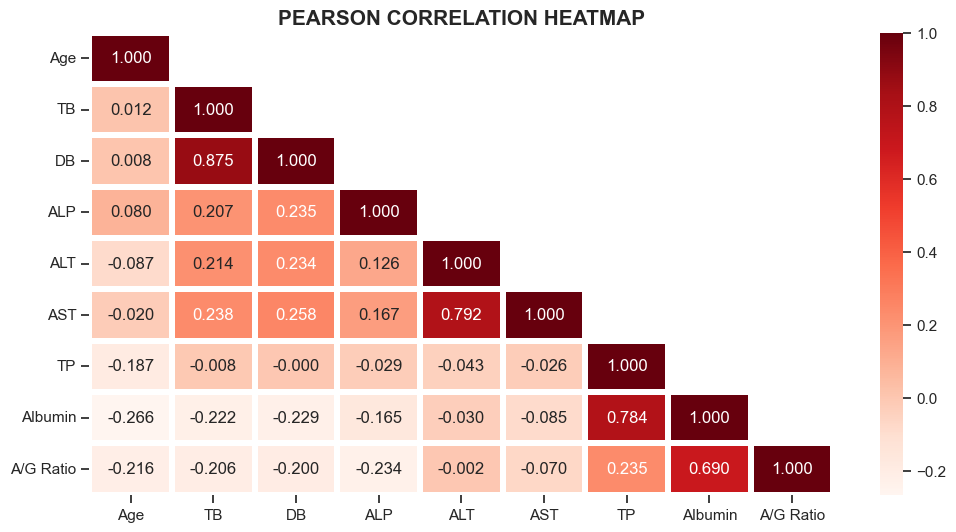

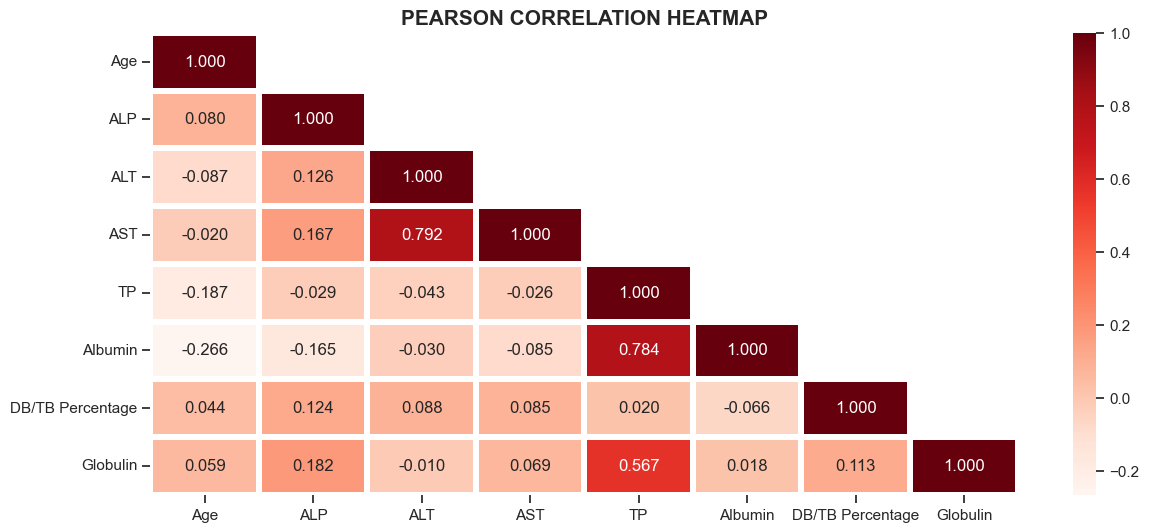

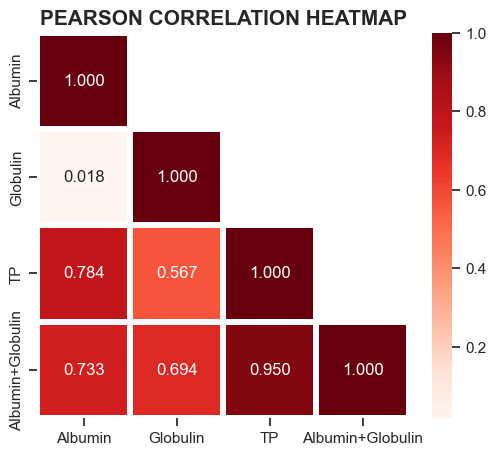

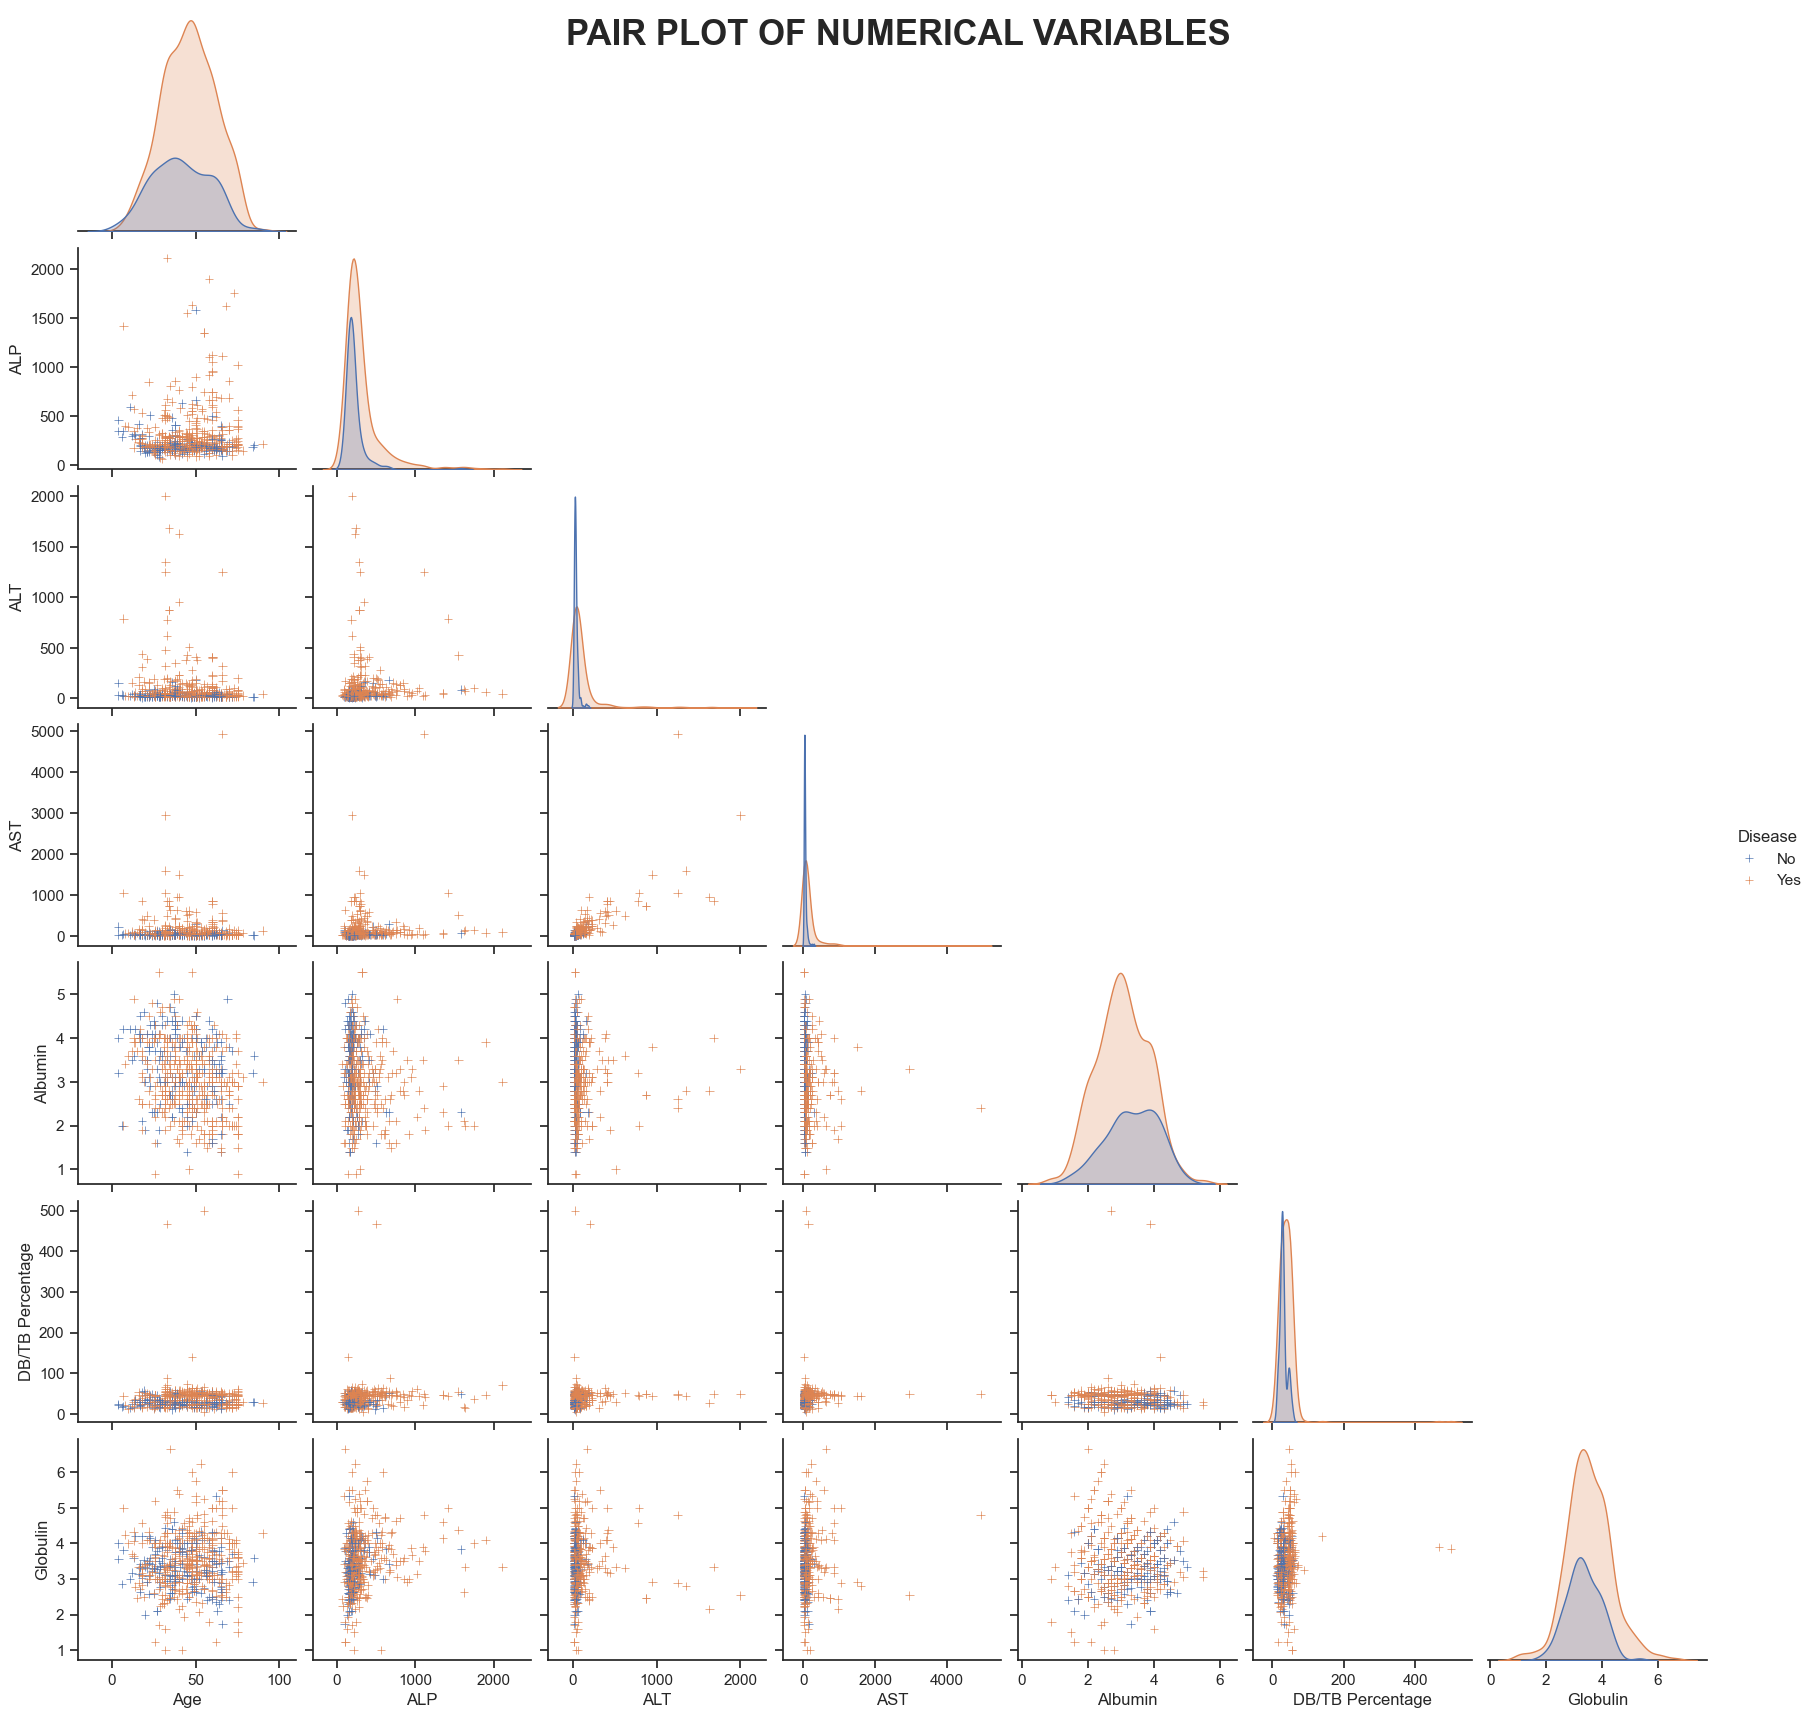

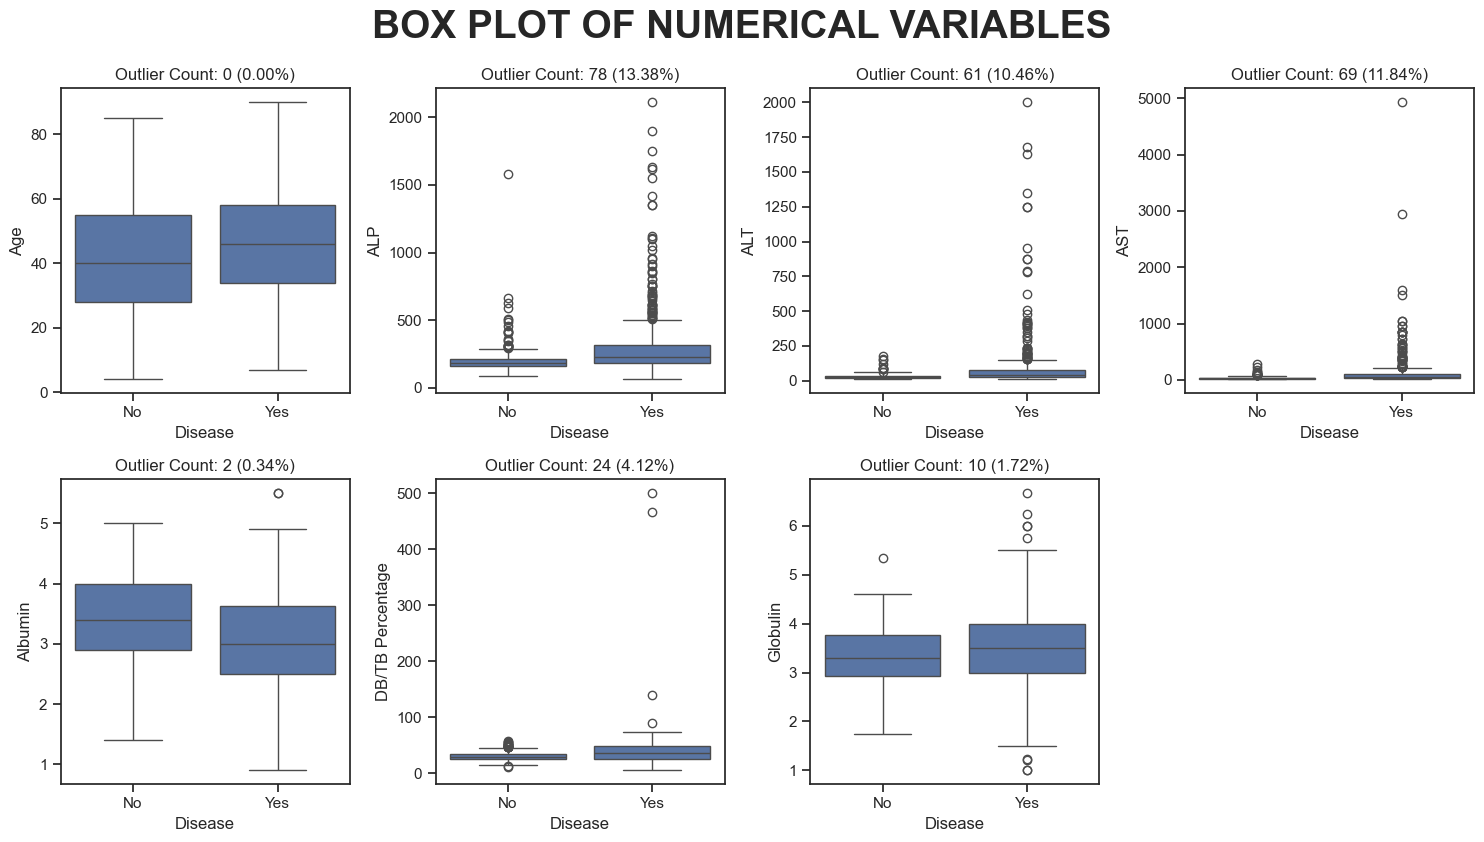

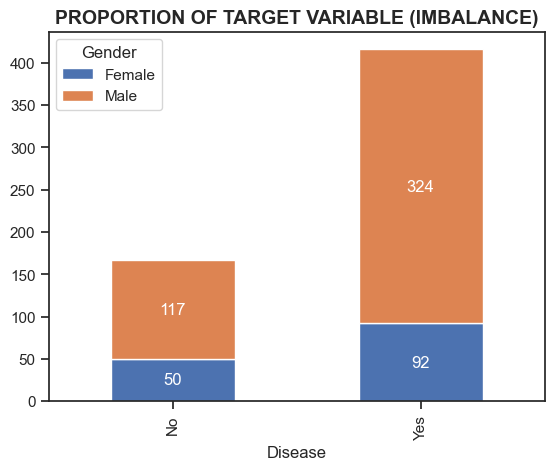

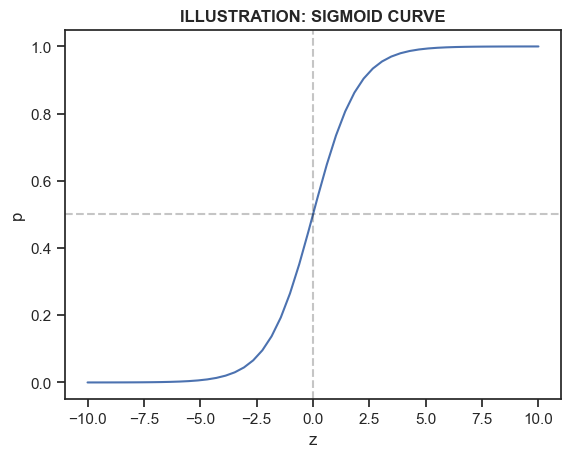

X Train: (624, 8)
X Test: (208, 8)
y Train: (624,)
y Test: (208,)
Optimization terminated successfully.
         Current function value: 0.559618
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.561719
         Iterations 8


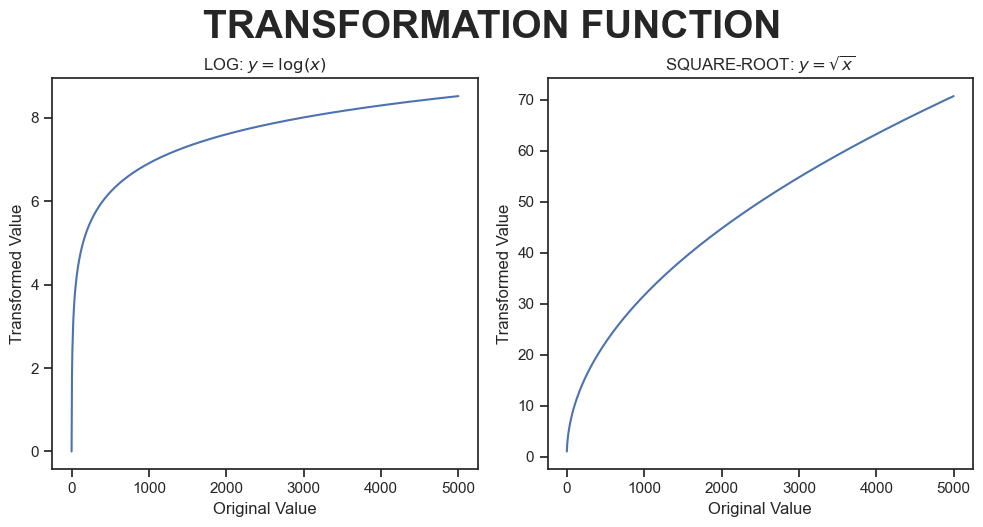

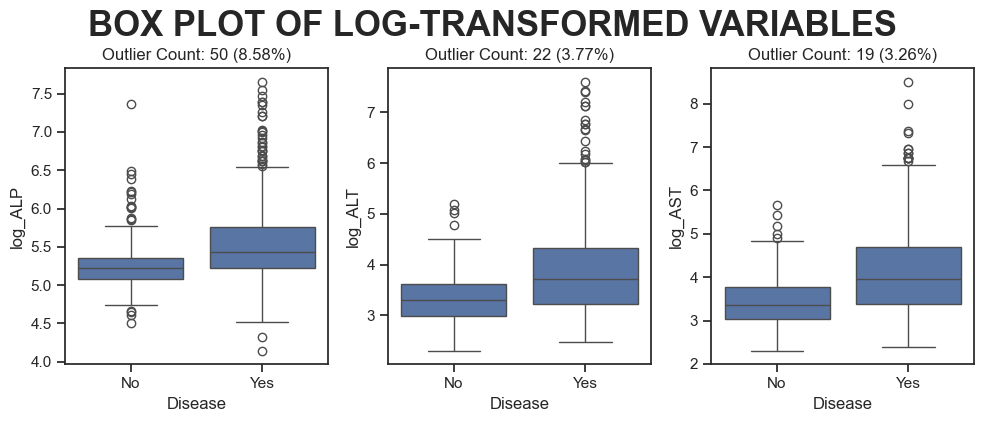

Optimization terminated successfully.
         Current function value: 0.558624
         Iterations 6


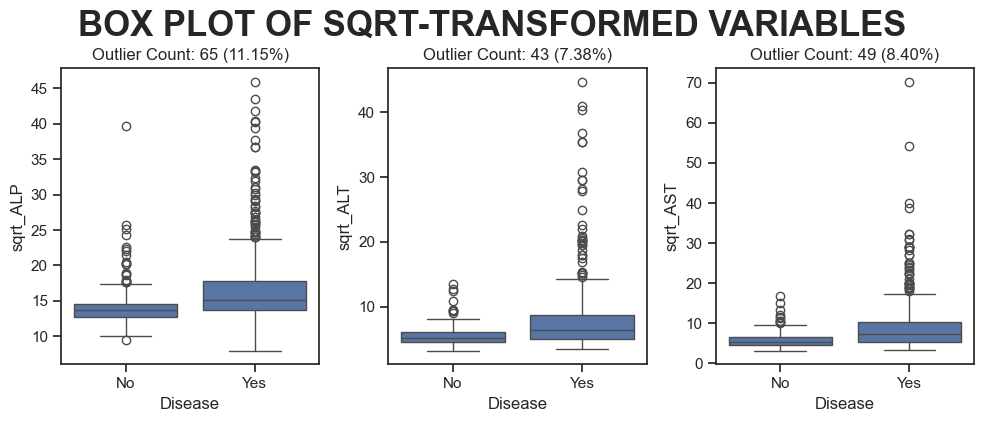

Optimization terminated successfully.
         Current function value: 0.558037
         Iterations 7


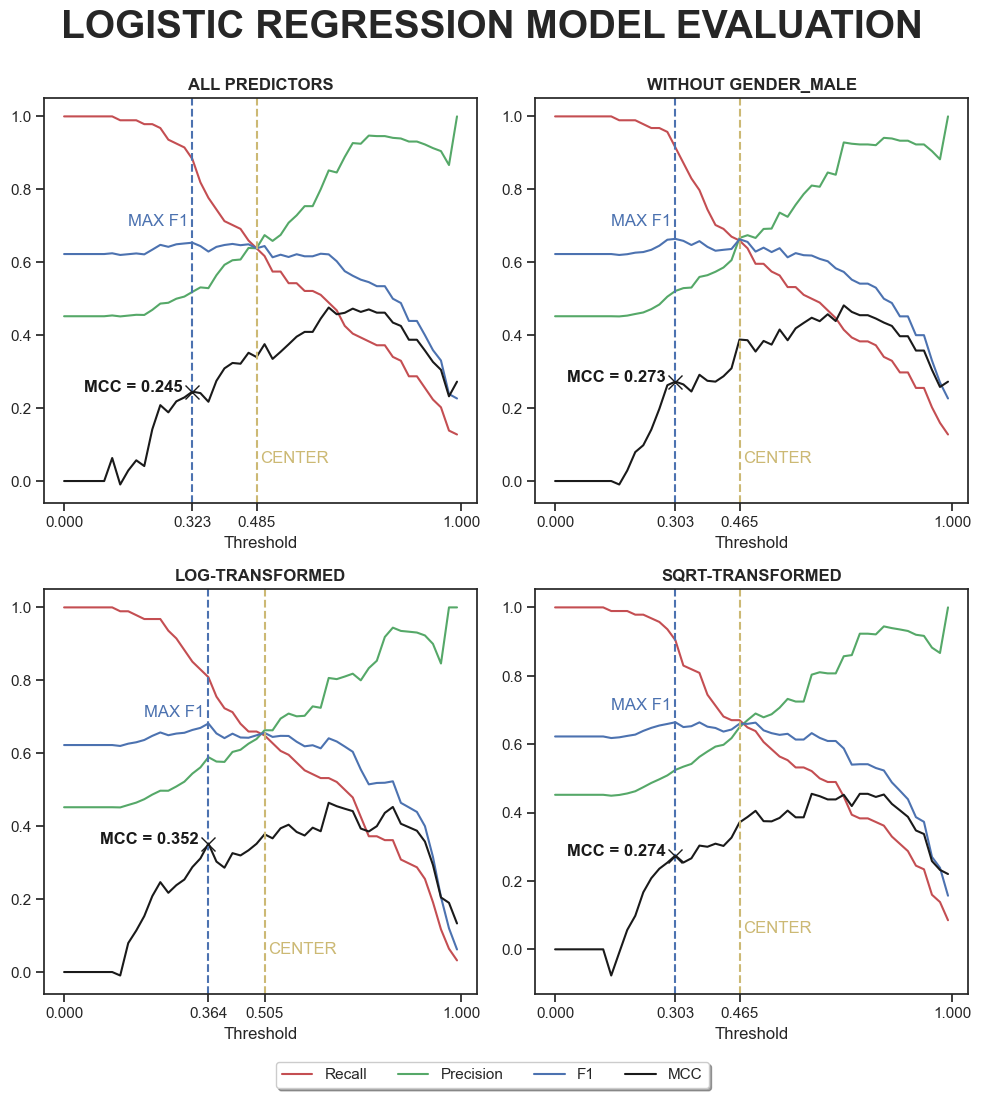


Comparison of Age 20 with Age 21
Logit Difference: 0.01964
Ratio of Odds: 1.01983
Ratio of Probability: 1.00464

Comparison of Age 21 with Age 22
Logit Difference: 0.01964
Ratio of Odds: 1.01983
Ratio of Probability: 1.00457

Comparison of Age 22 with Age 23
Logit Difference: 0.01964
Ratio of Odds: 1.01983
Ratio of Probability: 1.00450


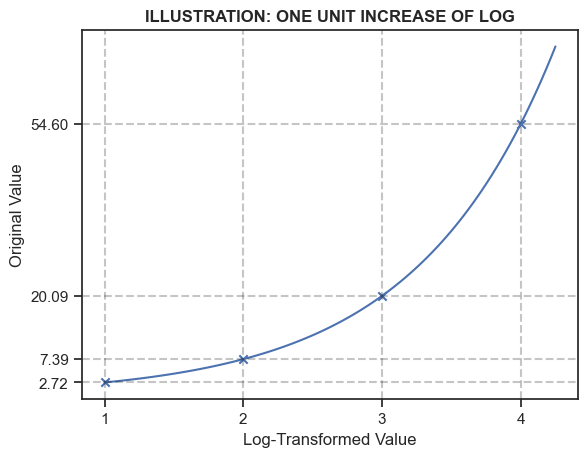

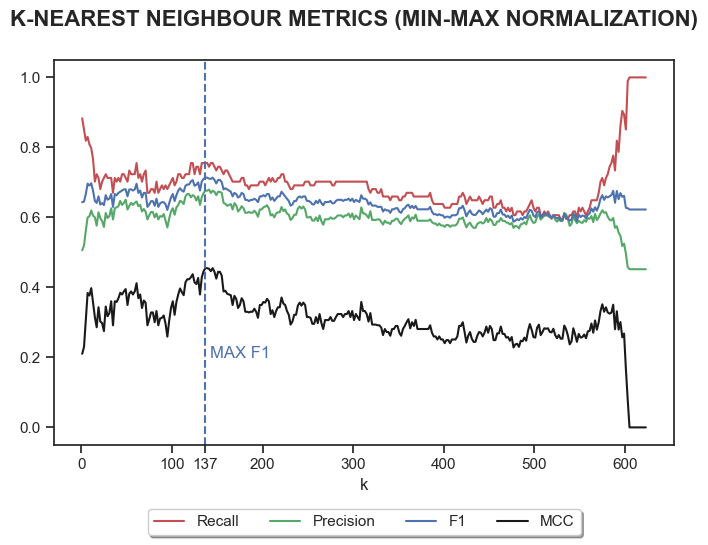

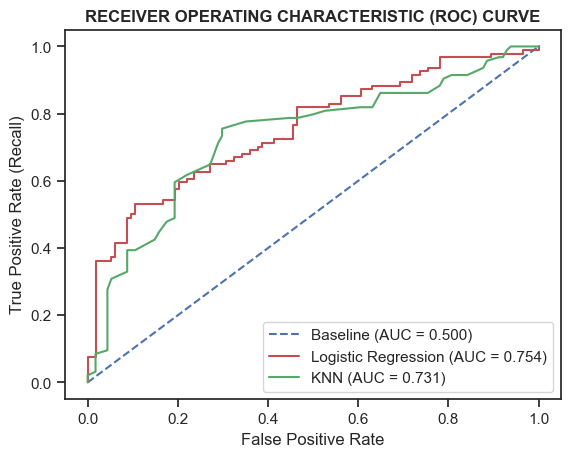

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB
Gender : Index(['Female', 'Male'], dtype='object')
Disease : Index(['No', 'Yes'], dtype='ob

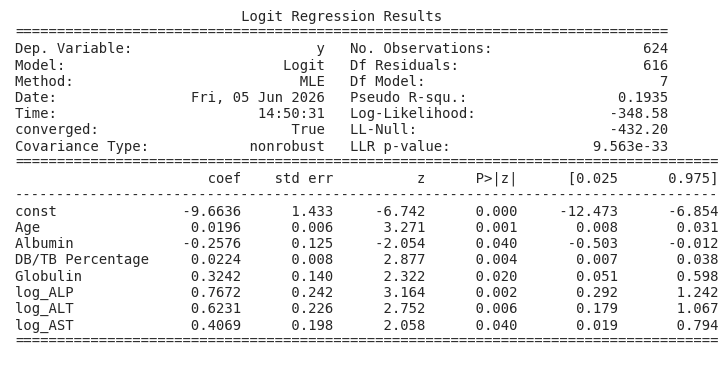

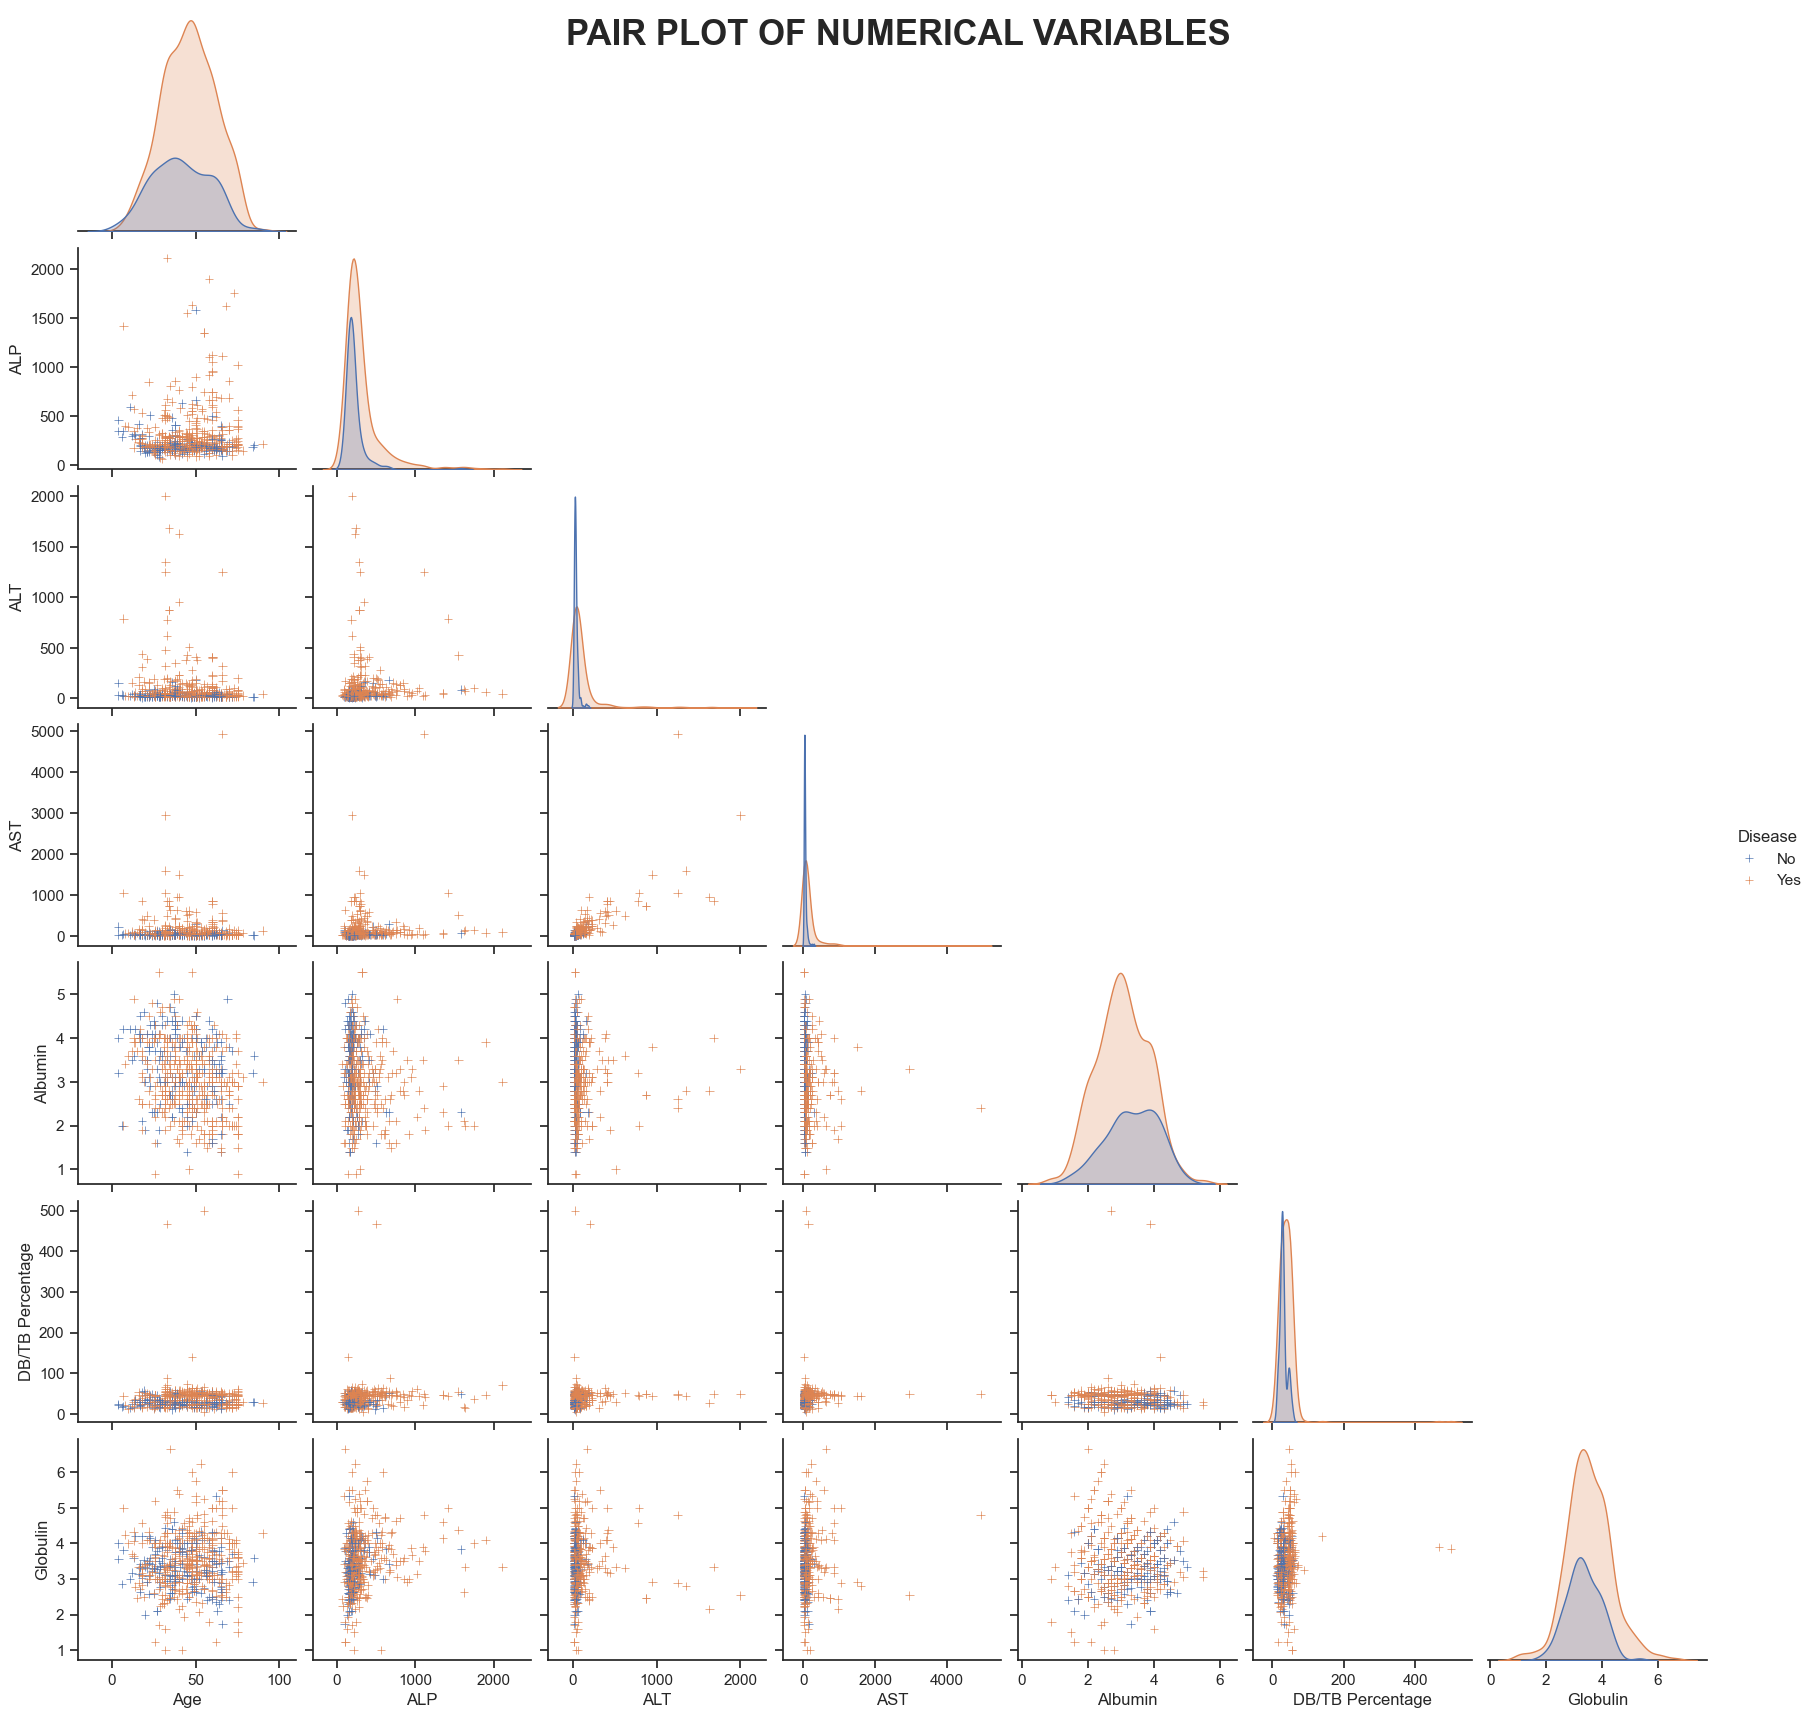

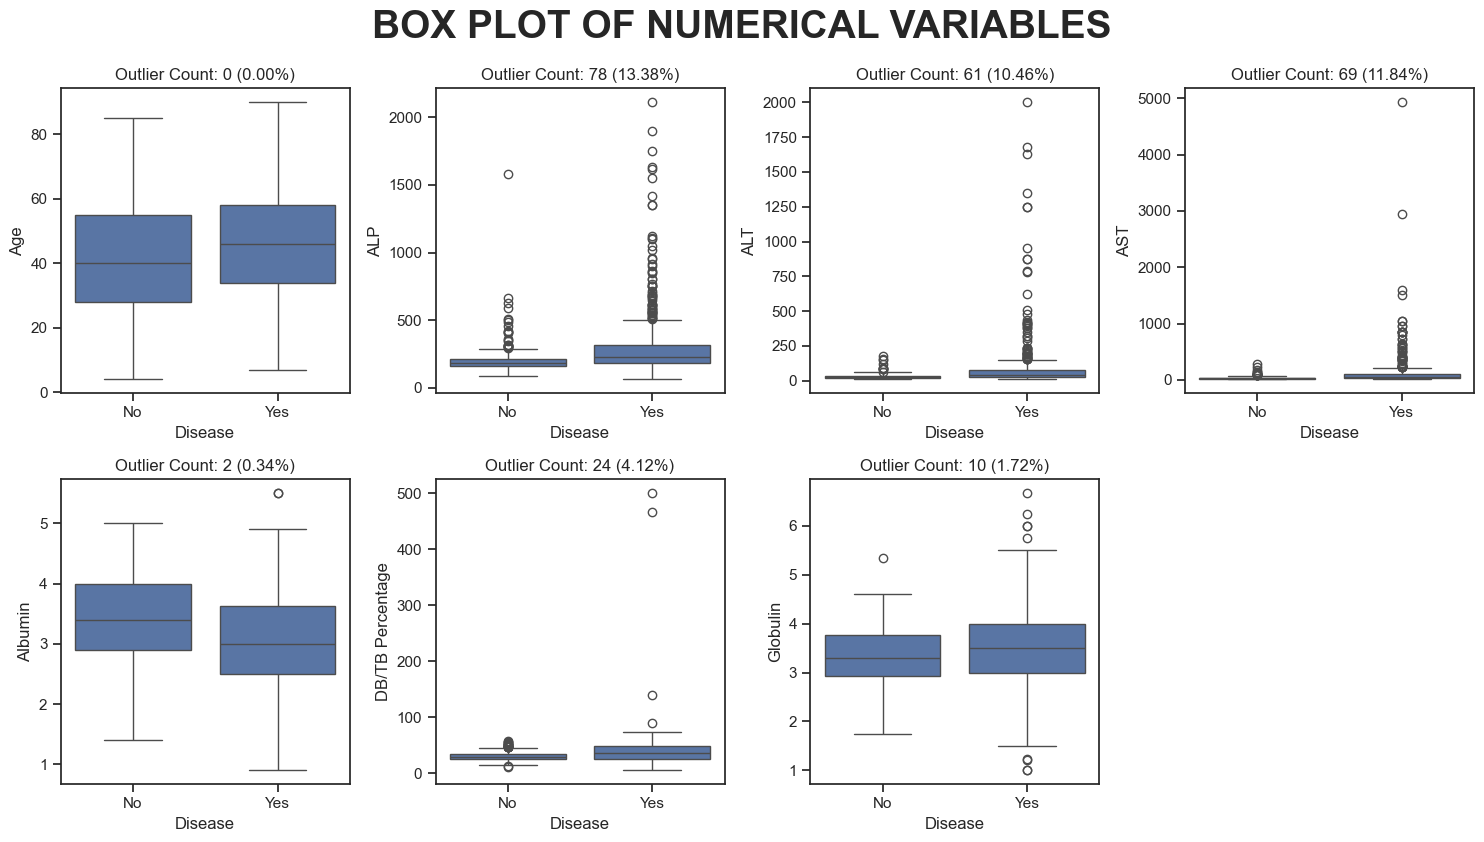

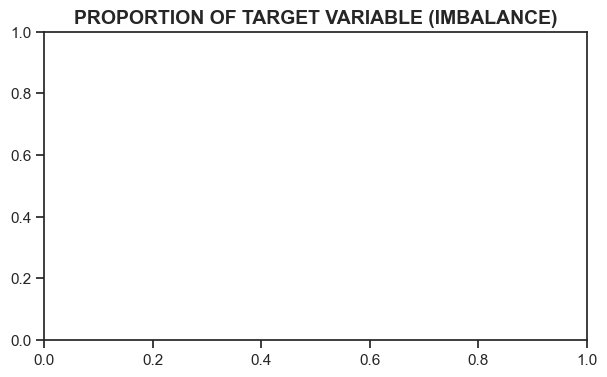

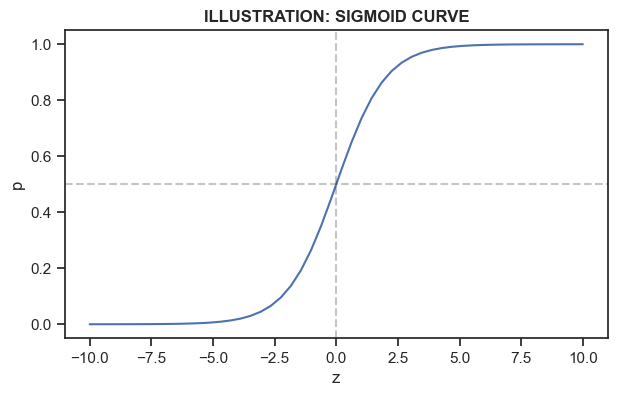

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB
Gender : Index(['Female', 'Male'], dtype='object')
Disease : Index(['No', 'Yes'], dtype='ob

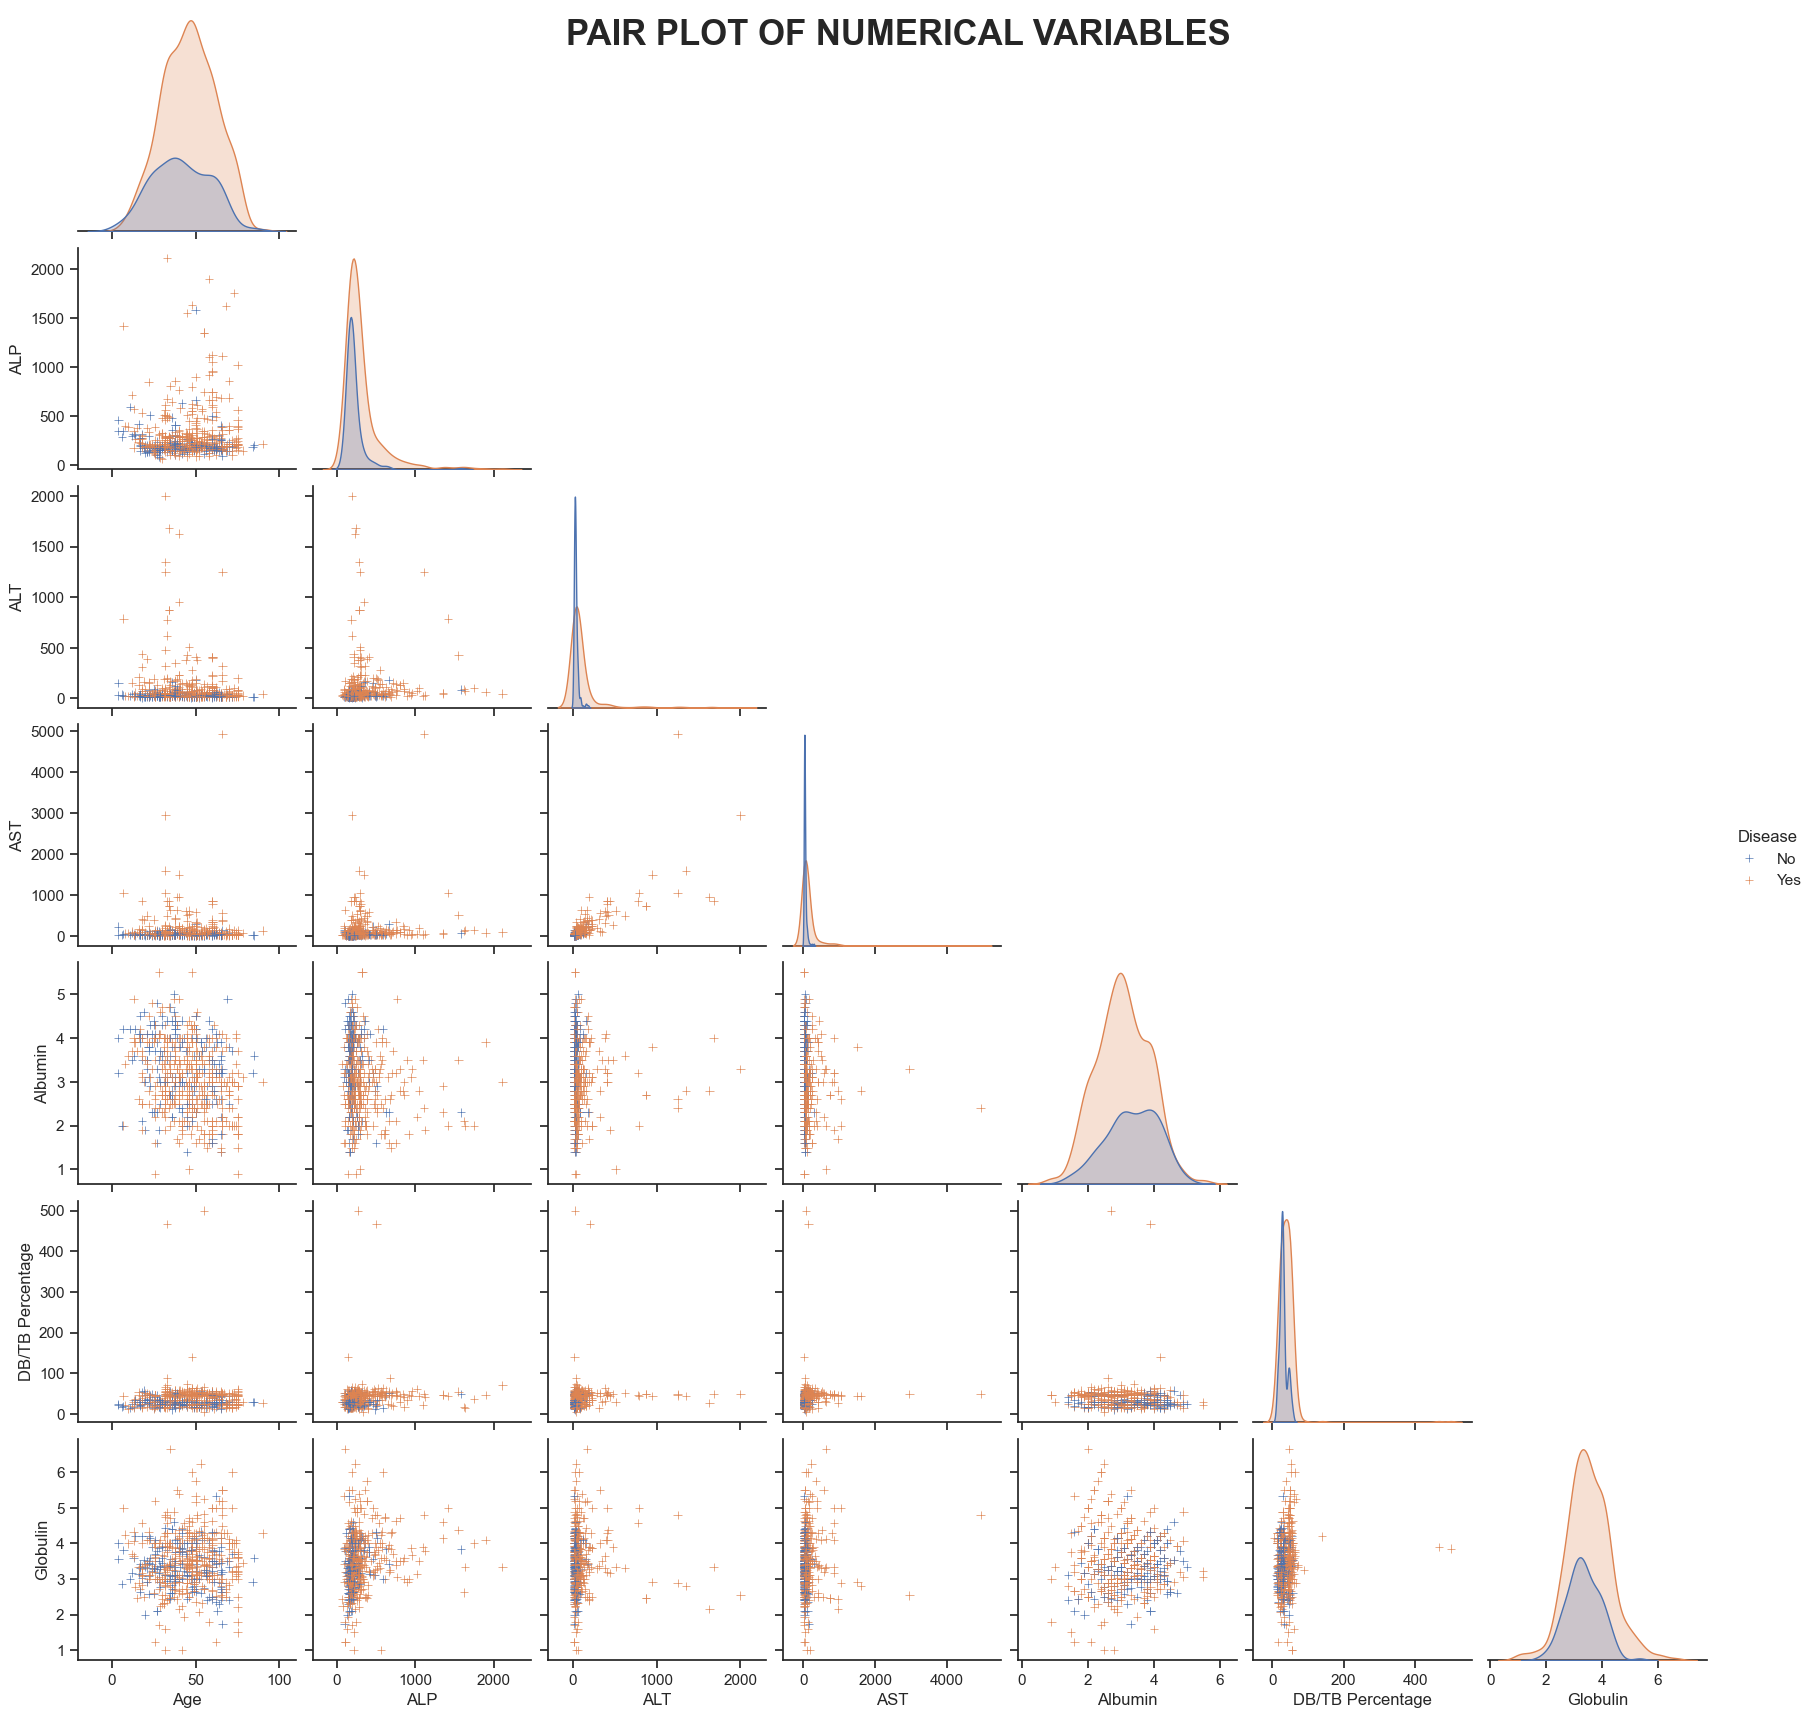

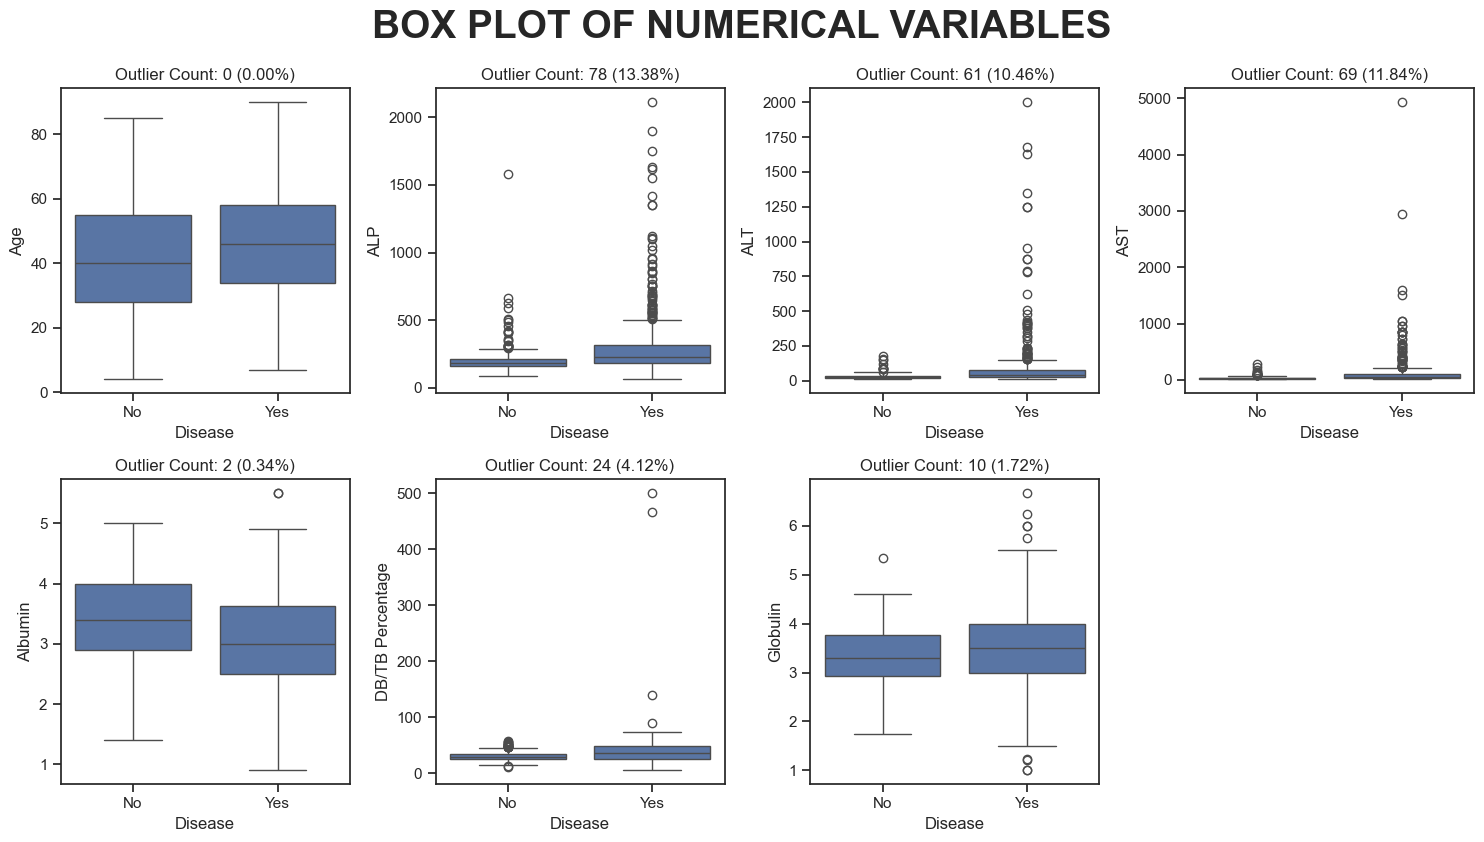

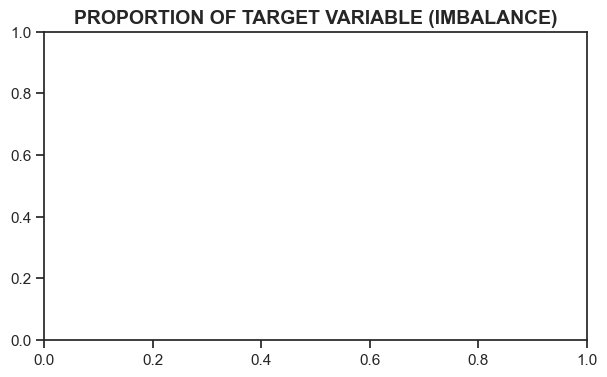

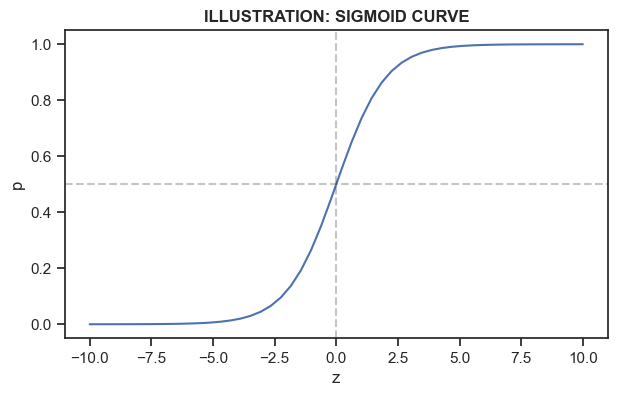

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB
Gender : Index(['Female', 'Male'], dtype='object')
Disease : Index(['No', 'Yes'], dtype='ob

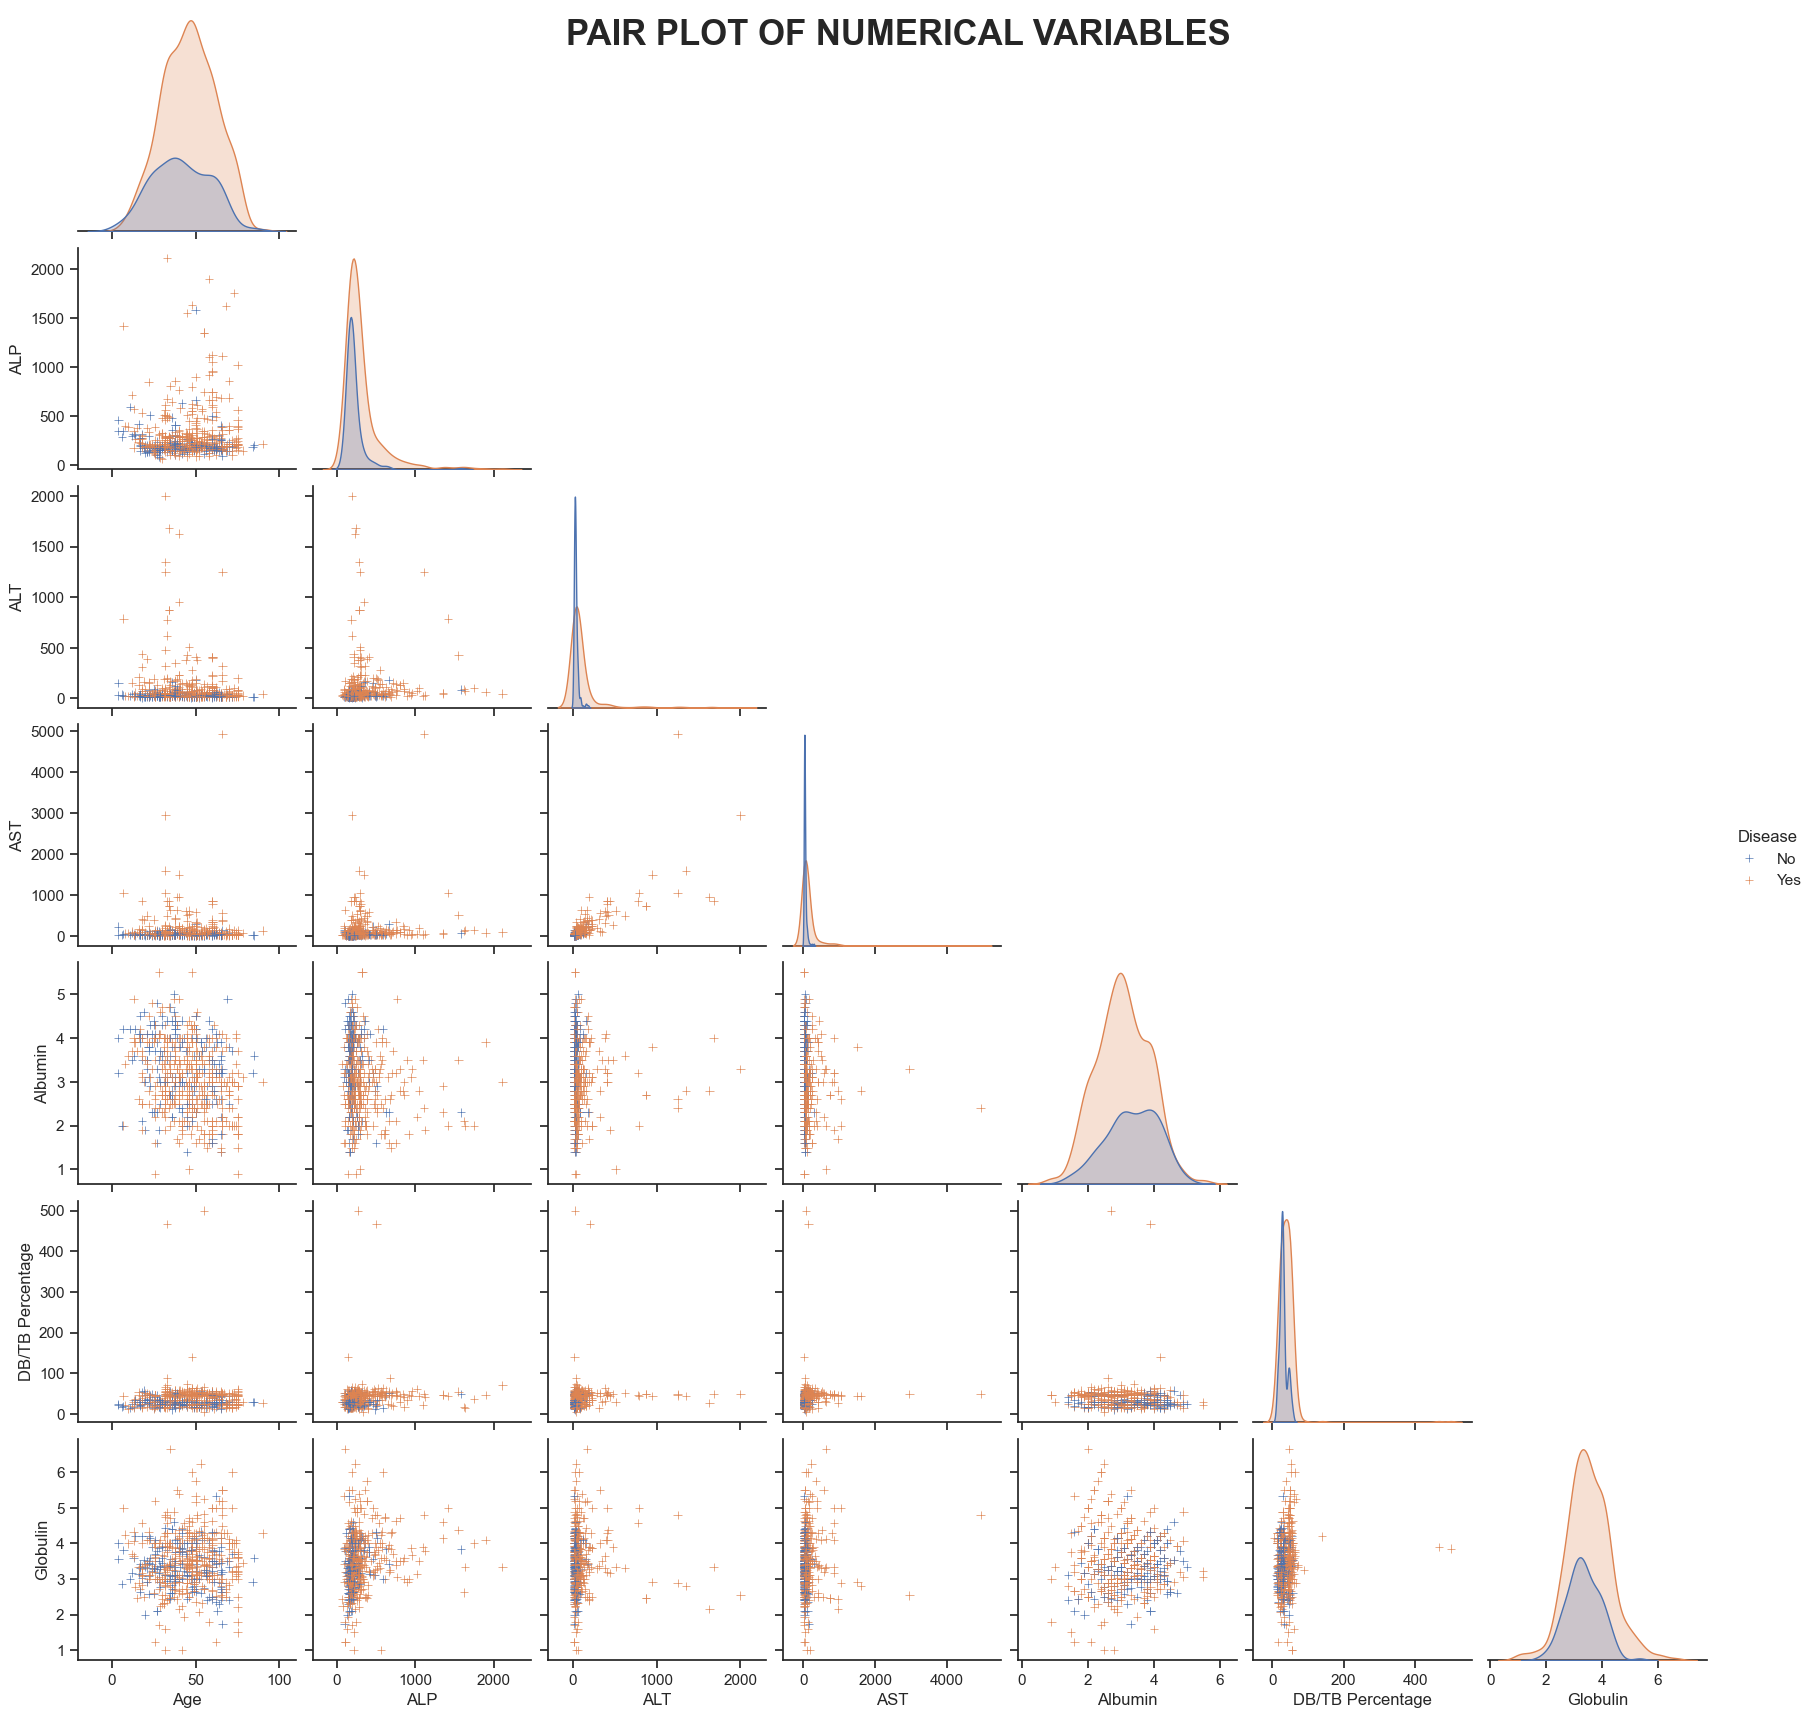

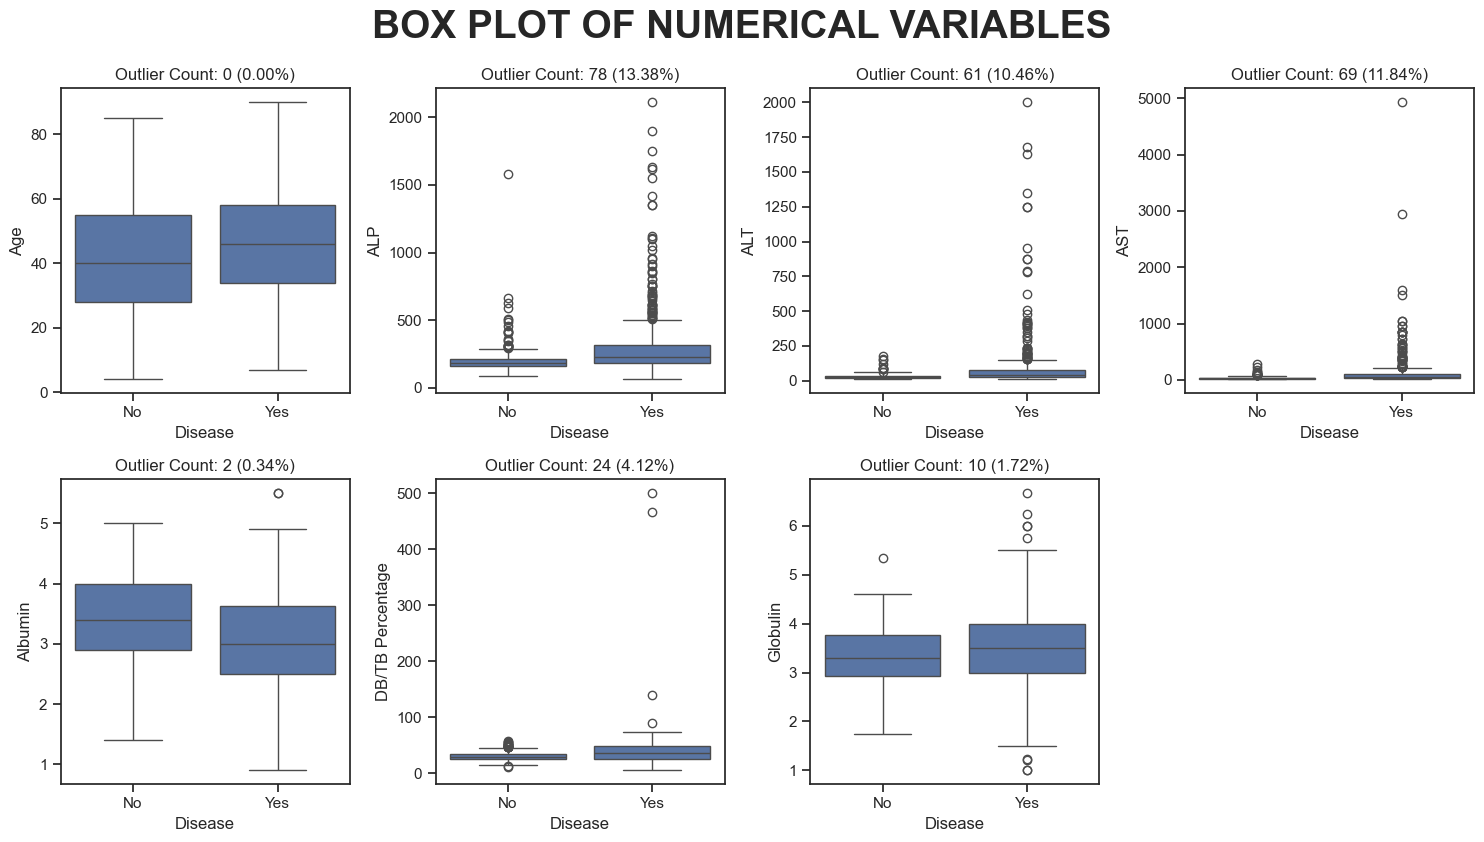

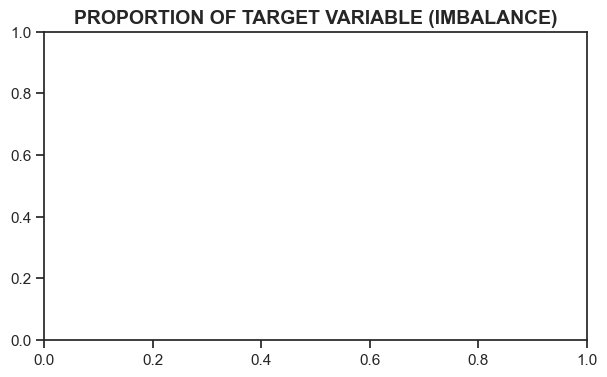

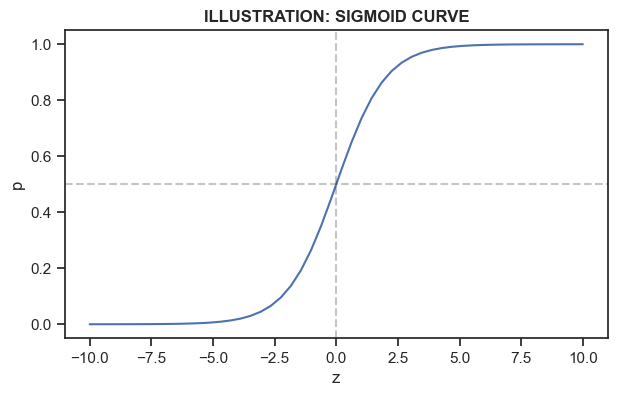

In [12]:
#**********************Tkinter starts****************
def browseFiles():
        global filename 
        filename = filedialog.askopenfilename(initialdir = "/",
                                          title = "Select a File",
                                          filetypes = (("Text files",
                                                        "*.txt*"),
                                                       ("all files",
                                                        "*.*")))
        label_file_explorer.configure(text="File Opened: "+filename)

filename="indian_liver_patient.csv"
# the main Tkinter window
window = Tk()

age_var = IntVar()
gender_var=IntVar()
alp_var=DoubleVar()
alt_var=DoubleVar()
ast_var=DoubleVar()
albumin_var=DoubleVar()
db_tb_var=DoubleVar()
globulin_var=DoubleVar()
# setting the title
window.title('Liver Disease Prediction')

# dimensions of the main window
window.geometry("950x650")
title_label = Label(window ,text="Liver Disease Prediction using KNN and Log Regression",font=("Arial", 20), relief=RIDGE)
browse_frame= Frame(window, borderwidth=2, width=400, relief=RAISED)
train_frame= Frame(window, borderwidth=2, width=400, relief=RAISED)
label_file_explorer = Label(browse_frame,
                            text = "Select a csv file to open",
                            width = 90,font="Arial 13 bold",fg="#144272",height=3,
                            relief=GROOVE
                            )
label_ProgressBar = Label(train_frame,
                            text = "Train the model..                   ",
                            font="Arial 13 bold",width=77,height=3,
                            fg="#144272",bg="#F9F9C5", relief=GROOVE)#FFB100 144272
  
      
button_explore = Button(browse_frame, height=2,
                        text = "Browse Files",font="Arial 12 bold",fg="#0A2647",
                        command = browseFiles)
# button that displays the plot
train_button = Button(master = train_frame,
					command = plot,
					height = 2,
					width = 12,font="Arial 12 bold",fg="#0A2647",
					text = "Train the Model",)
display_button = Button(master = window,
					command = displayResults,
					height = 1,
					width = 15,font="Arial 12 bold",fg="#0A2647",
					text = "Generate results")
progress = ttk.Progressbar(train_frame, orient = HORIZONTAL,
			length = 100, mode = 'determinate')

img_frame=Frame(window,borderwidth=1,bg="#001122",relief=GROOVE)
import os
from PIL import Image as PILImage
_bg_path = "Display result bg.png"
if not os.path.exists(_bg_path):
    PILImage.new("RGB", (350, 350), color=(0, 17, 34)).save(_bg_path)
img = Image.open(_bg_path)
image = img.resize((350,350))
img1 = ImageTk.PhotoImage(master=img_frame,image=image)

img = Image.open(_bg_path)
image = img.resize((350,350))
img2 = ImageTk.PhotoImage(master=img_frame,image=image)


img_Label = Label(img_frame, image=img1)
img_Label2 = Label(img_frame, image=img2)
#******************************************************
input_frame1= Frame(window, borderwidth=2,width=400, relief=RAISED)

age_label= Label(input_frame1, text="Age",height=2)
age_entry=Entry(input_frame1,textvariable=age_var)

male_radio= Radiobutton(input_frame1, text='Male', variable=gender_var, value=1)
female_radio =Radiobutton(input_frame1, text='Female', variable=gender_var, value=0)

alp_label= Label(input_frame1, text="ALP")
alp_entry=Entry(input_frame1,textvariable=alp_var)

alt_label= Label(input_frame1, text="ALT")
alt_entry=Entry(input_frame1,textvariable=alt_var)
#**********************************************************
input_frame2=Frame(window,borderwidth=2,width=400, relief=RAISED)
ast_label= Label(input_frame2, text="AST", height=2)
ast_entry=Entry(input_frame2,textvariable=ast_var, width=10)

albumin_label= Label(input_frame2, text="Albumin")
albumin_entry=Entry(input_frame2,textvariable=albumin_var,width=13)

db_tb_label= Label(input_frame2, text="DB/TB Percentage")
db_tb_entry=Entry(input_frame2,textvariable=db_tb_var, width=13)

globulin_label= Label(input_frame2, text="Globulin")
globulin_entry=Entry(input_frame2,textvariable=globulin_var, width=13)
#**********************************************
predict_frame=Frame(window,borderwidth=2,width=400, relief=RAISED)
predict_button=Button(master = predict_frame,
					command = predictResults,
					height = 1,
					width = 13,font="Arial 12 bold",fg="#0A2647",
					text = "Predict Output")
predict_label = Label(predict_frame,
                            text = "Click to Predict Output",
                            width = 42,font="Arial 13 bold",fg="#144272",height=2,
                            relief=GROOVE
                            )
predict_progress = ttk.Progressbar(predict_frame, orient = HORIZONTAL,
			length = 100, mode = 'determinate')
# place the button
# in main window
title_label.pack(pady=20, padx=10)

browse_frame.pack( padx=20)
button_explore.pack(side=LEFT, padx=20)
label_file_explorer.pack(side=LEFT)

train_frame.pack(padx=20)
train_button.pack(side=LEFT, padx=20)
progress.pack(side=LEFT)
label_ProgressBar.pack(side=LEFT,padx=10)

input_frame1.pack(pady=(10,0))
age_label.pack(side=LEFT, padx=(10,10))
age_entry.pack(side=LEFT,padx=(0,20))
male_radio.pack(side=LEFT,padx=(0,10))
female_radio.pack(side=LEFT,padx=(0,20))
alp_label.pack(side=LEFT,padx=(0,10))
alp_entry.pack(side=LEFT,padx=(0,20))
alt_label.pack(side=LEFT,padx=(0,10))
alt_entry.pack(side=LEFT,padx=(0,20))

input_frame2.pack(pady=10)
ast_label.pack(side=LEFT, padx=(10,10))
ast_entry.pack(side=LEFT,padx=(0,20))
albumin_label.pack(side=LEFT, padx=(10,10))
albumin_entry.pack(side=LEFT,padx=(0,20))
db_tb_label.pack(side=LEFT, padx=(10,10))
db_tb_entry.pack(side=LEFT,padx=(0,20))
globulin_label.pack(side=LEFT, padx=(10,10))
globulin_entry.pack(side=LEFT,padx=(0,20))

predict_frame.pack()
predict_button.pack(side=LEFT, padx=(10,0))
predict_progress.pack(side=LEFT, padx=10)
predict_label.pack(side=LEFT)

display_button.pack(pady=10)

img_frame.pack()
img_Label.pack(side=LEFT, padx=20, pady=20)
img_Label2.pack(side="left",padx=20, pady=20)


# run the gui
window.mainloop()